## Import

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [12]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [13]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_quantile_14"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [14]:
override = True
use_preds = False
save = True
show = True
scaler_name = "quantile"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


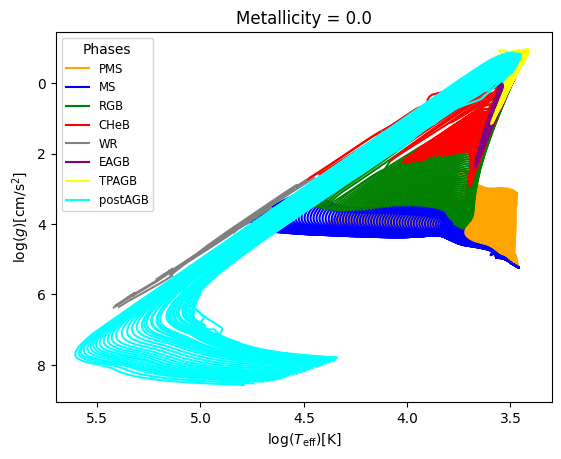

In [15]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.00,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.00,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.00,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.05,4.482577,4.350883,0.0,-0.25,12.925175,0.596074
4,5.05,4.485667,4.349692,0.0,-0.25,13.105490,0.600130
...,...,...,...,...,...,...,...
519286,10.30,3.602322,1.827453,3.0,0.50,0.866616,1.274247
519287,10.30,3.600999,1.809405,3.0,0.50,0.866614,1.283270
519288,10.30,3.599710,1.791489,3.0,0.50,0.866612,1.292228
519289,10.30,3.598418,1.773621,3.0,0.50,0.866610,1.301161


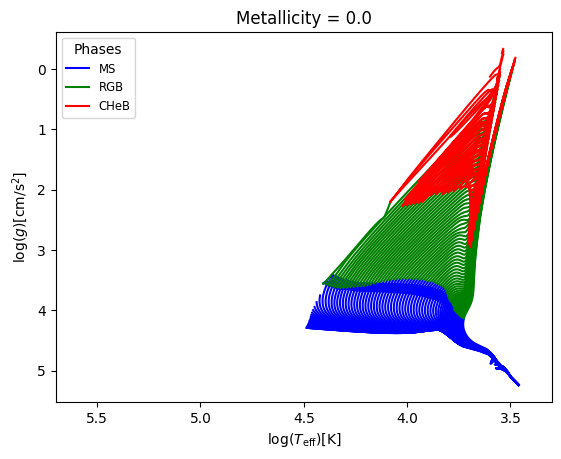

In [16]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [17]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.4629, Median : 8.5

log_Teff  : Range : 3.34 - 4.6345, Mean : 3.9346, Median : 3.8644

log_g  : Range : -1.08 - 5.4331, Mean : 3.5485, Median : 3.9492

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 13.9995, Mean : 3.398, Median : 2.0471

log_R  : Range : -1.0 - 3.0828, Mean : 0.6067, Median : 0.5386



In [18]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 13.998624815474695
Median value in train data for the star_mass parameter: 2.0464342686349397
Mean value in train data for the star_mass parameter: 3.3973846370701644

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 13.99946885003588
Median value in test data for the star_mass parameter: 2.048860774010381
Mean value in test data for the star_mass parameter: 3.399812923045874

Range in test data for the log_R parameter : -0.9974234436680278 - 3.0827540579576227
Median value in test data for the log_R parameter: 0.5398730026691951
Mean value in test data for the log_R parameter: 0.6057854356870224

(389468, 4) (129823, 4)
(38

## Model training

### Linear regression

In [19]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.6103506429666616
  RMSE :  2.0570888045170608
  MAE :  1.6239170217540932
  MedAE :  1.2548585562927206
  CORR :  0.7935599655861477
  MAX_ER :  7.662871606658664
  Percentiles : 
    75th percentile :  2.358253035211126
    90th percentile :  3.2855703048452125
    95th percentile :  3.9097440895943185
    99th percentile :  5.949331531690476

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.7712701455977748
  RMSE :  1.5522172208561853
  MAE :  1.0647042108771305
  MedAE :  0.8167968366715226
  CORR :  0.9045999981330486
  MAX_ER :  6.833819172289362
  Percentiles : 
    75th percentile :  1.2326411078167796
    90th percentile :  1.9558074501707365
    95th percentile :  3.70487358

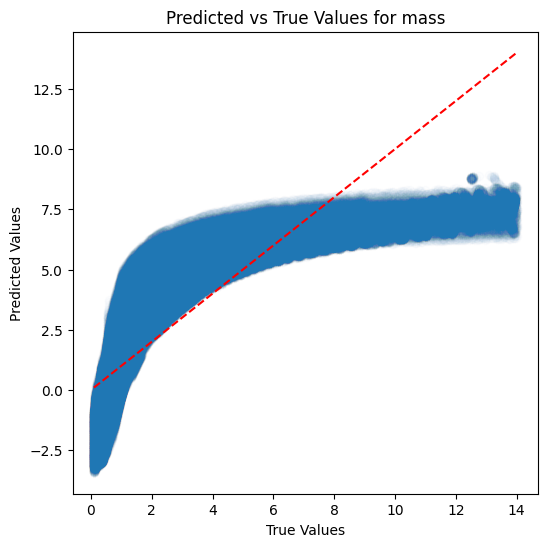

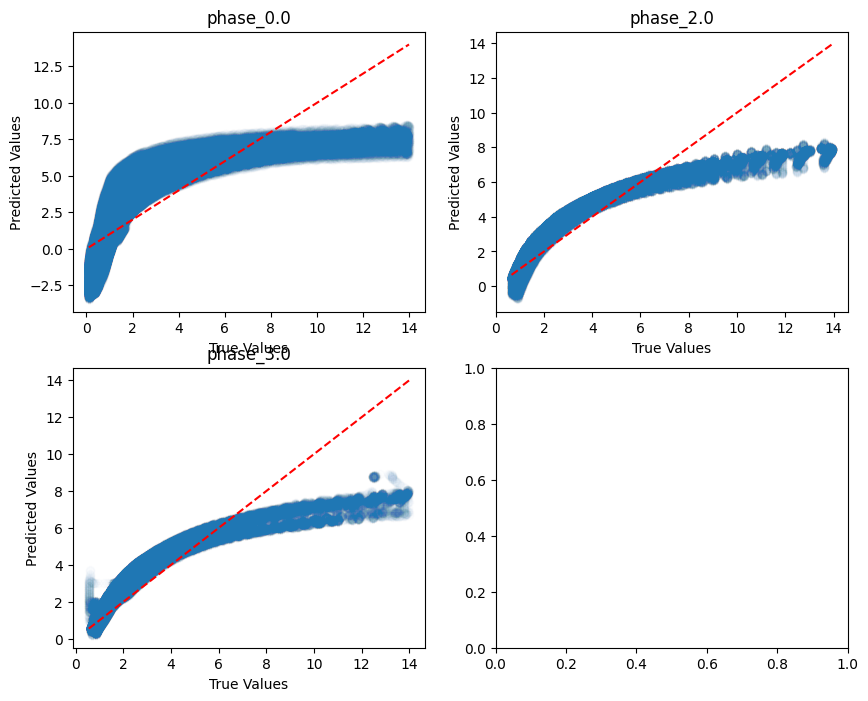

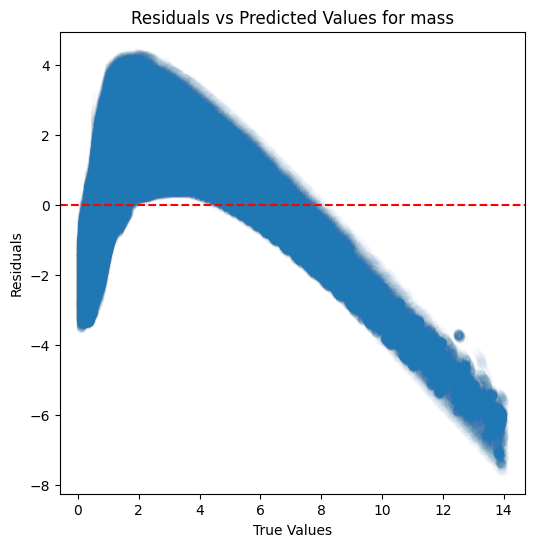

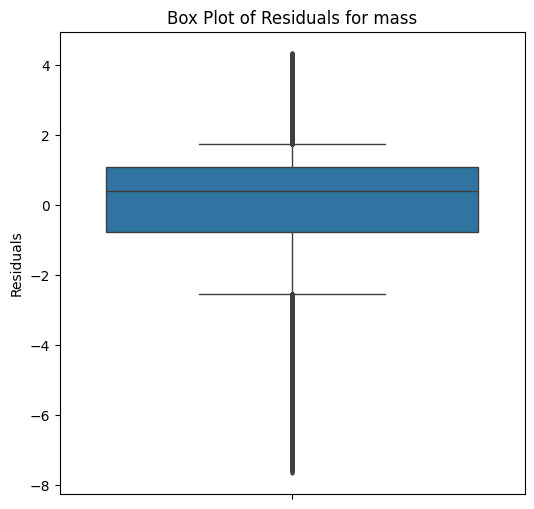

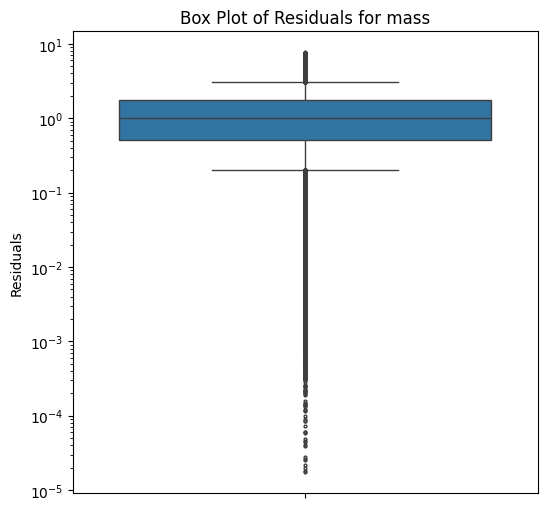

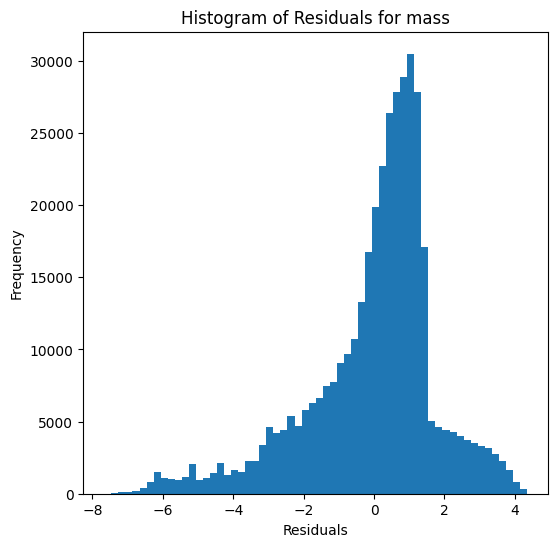

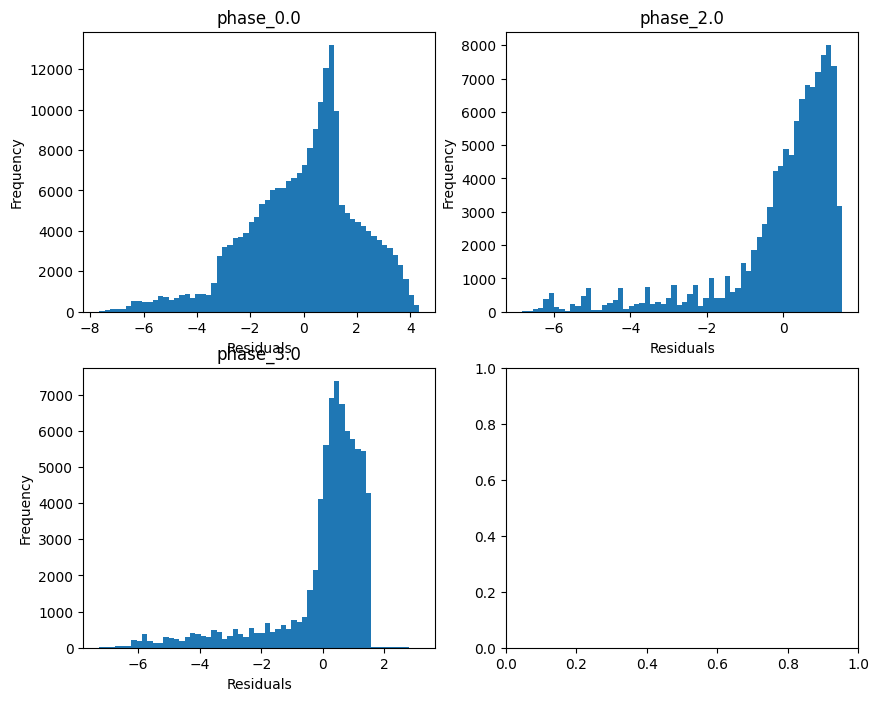

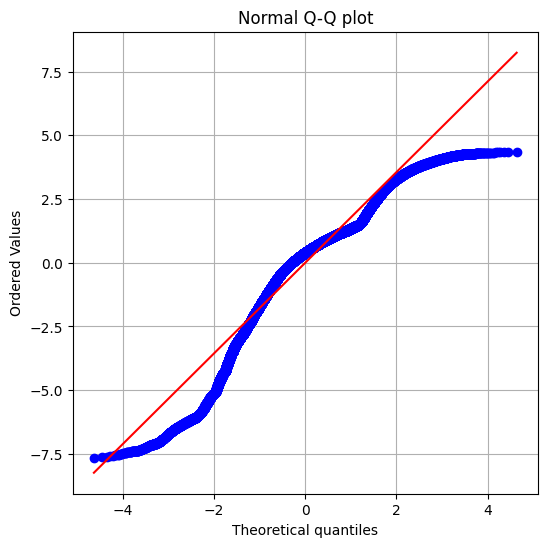

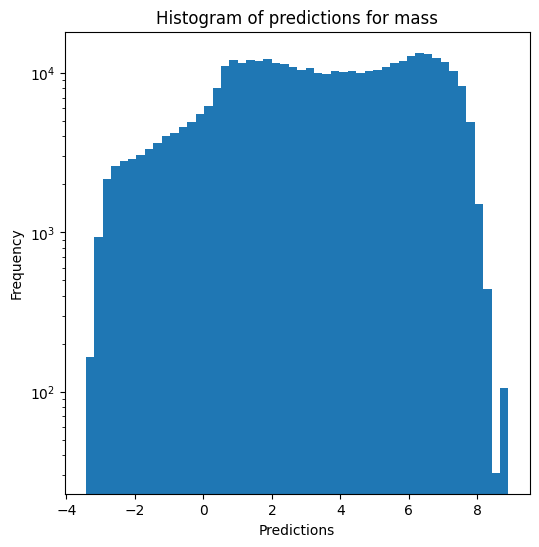

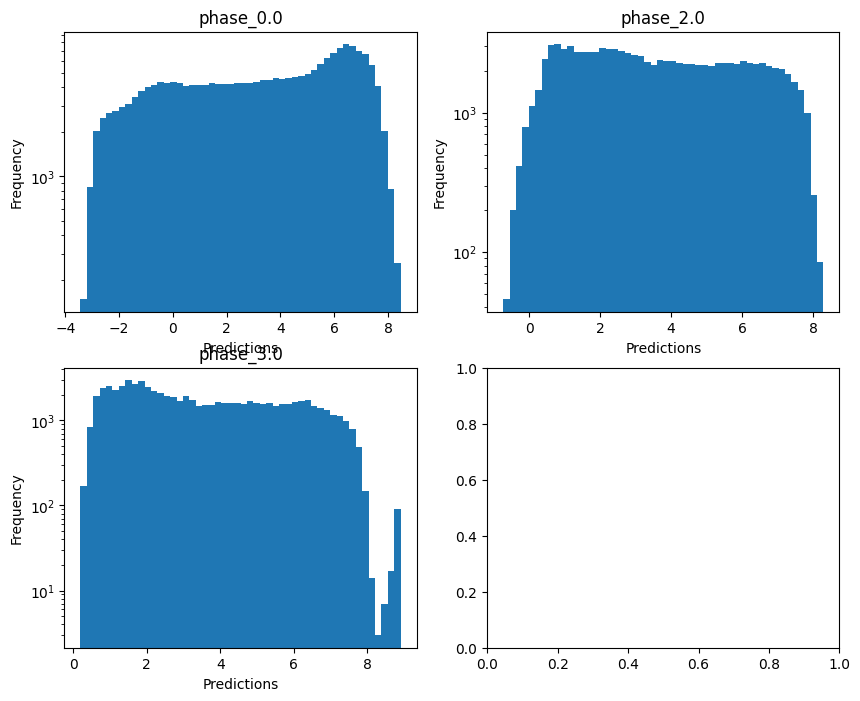

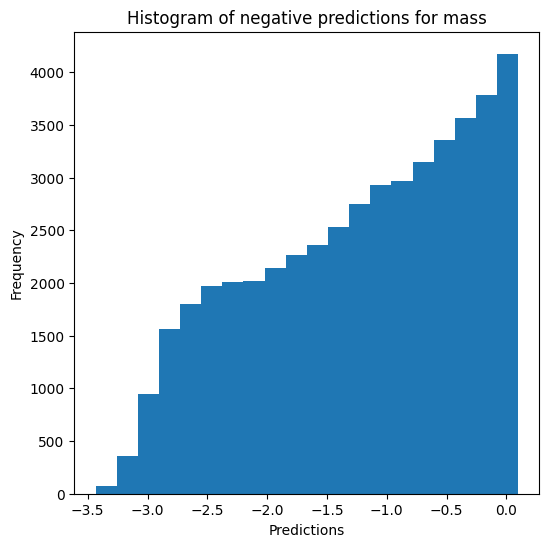


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.8740745598606026
  RMSE :  0.15029508563464988
  MAE :  0.1152695081707429
  MedAE :  0.08612585927722055
  CORR :  0.9376628167977924
  MAX_ER :  0.8315698925490143
  Percentiles : 
    75th percentile :  0.16931278974768862
    90th percentile :  0.2495729058791632
    95th percentile :  0.30593315895007667
    99th percentile :  0.4092964891973552

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.935083757029717
  RMSE :  0.12699676836191212
  MAE :  0.09977803580053655
  MedAE :  0.09216020105278722
  CORR :  0.9741222467228753
  MAX_ER :  0.8773012026577014
  Percentiles : 
    75th percentile :  0.13140814377760196
    90th percentile :  0.16081870653652192
    95th percentile :  0.19678807390957612
    99th percentile :  0.44933054490025276

radius results for the phase category

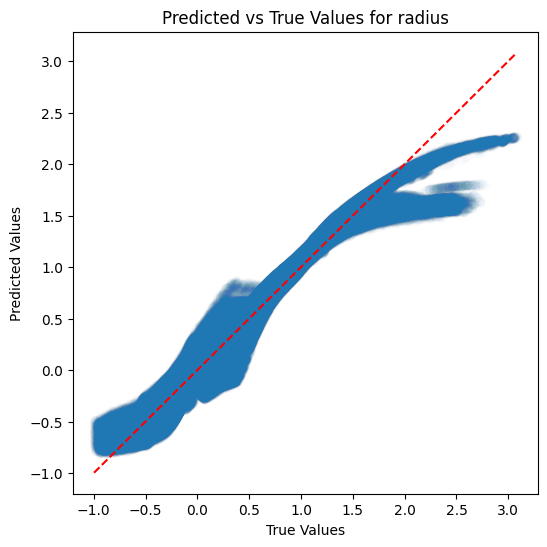

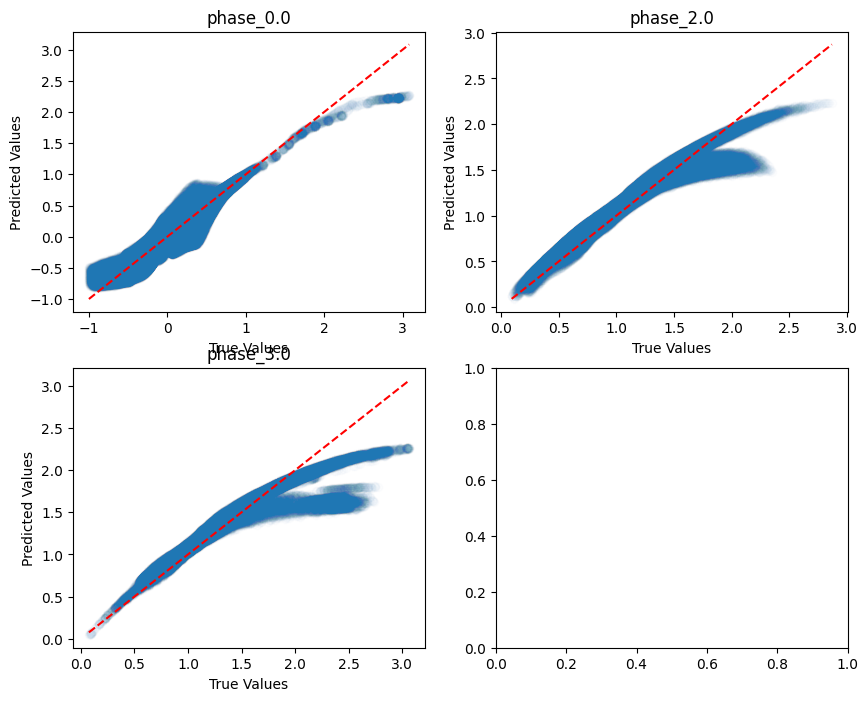

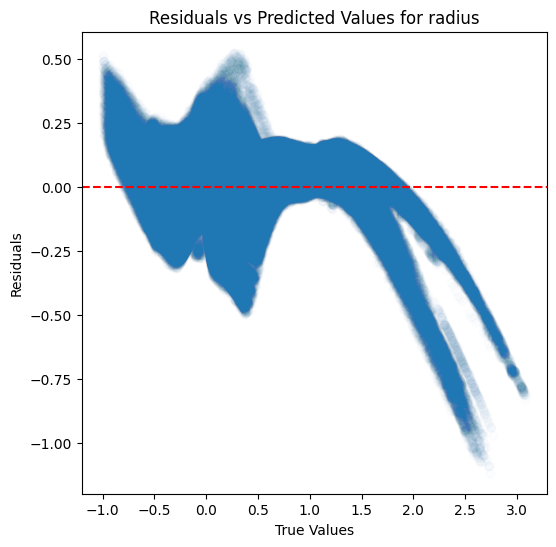

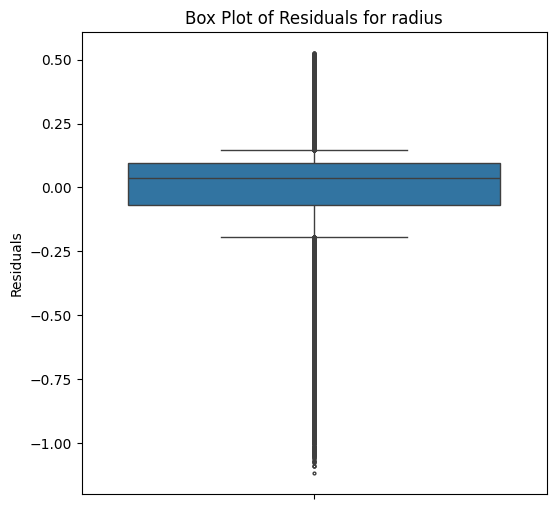

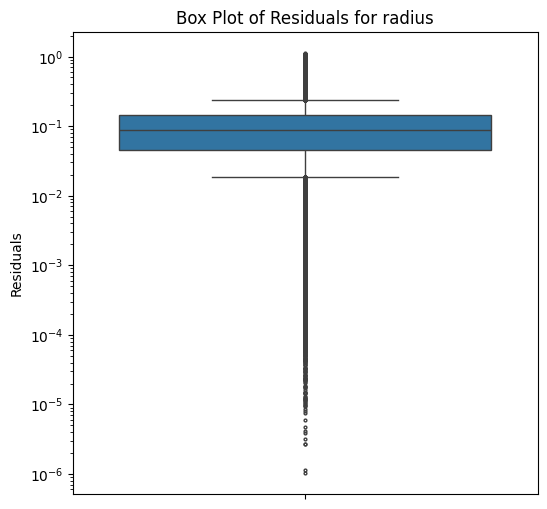

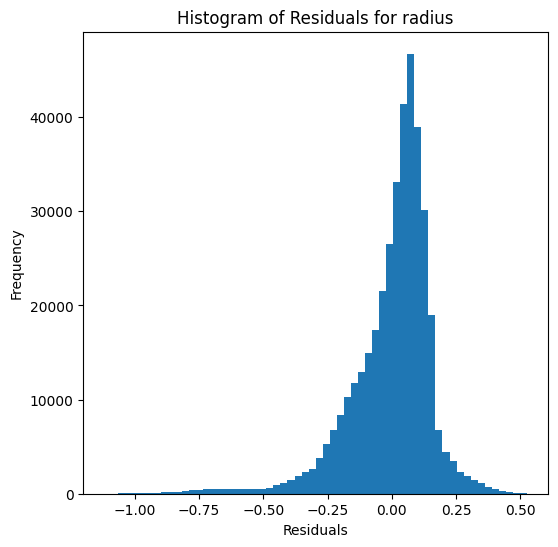

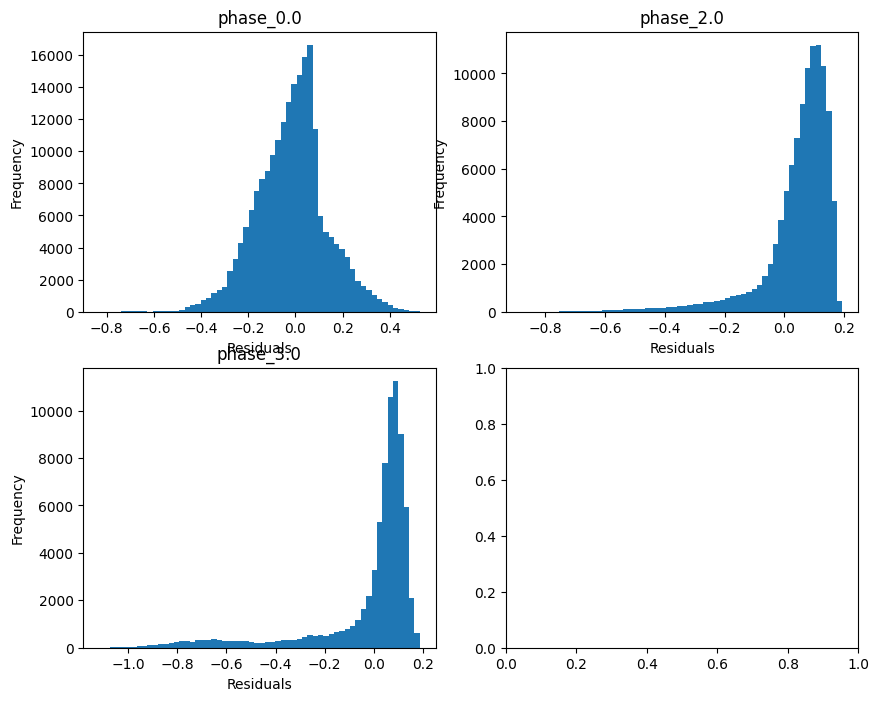

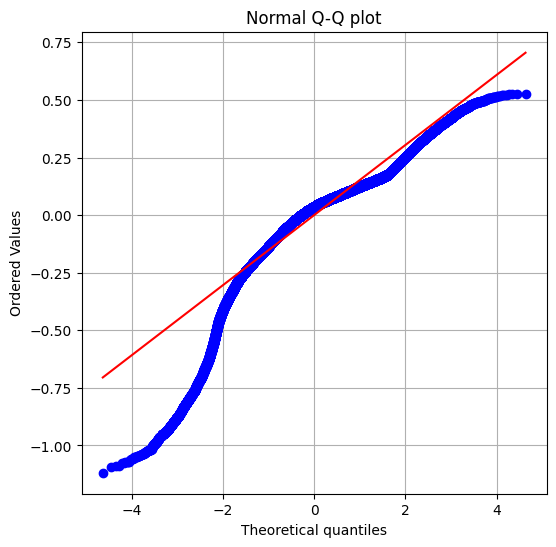

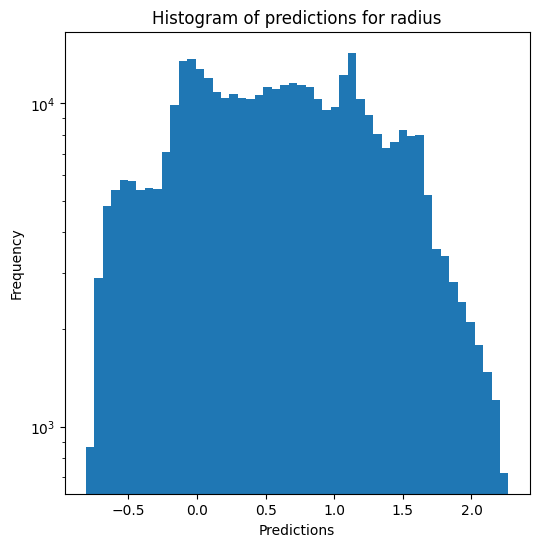

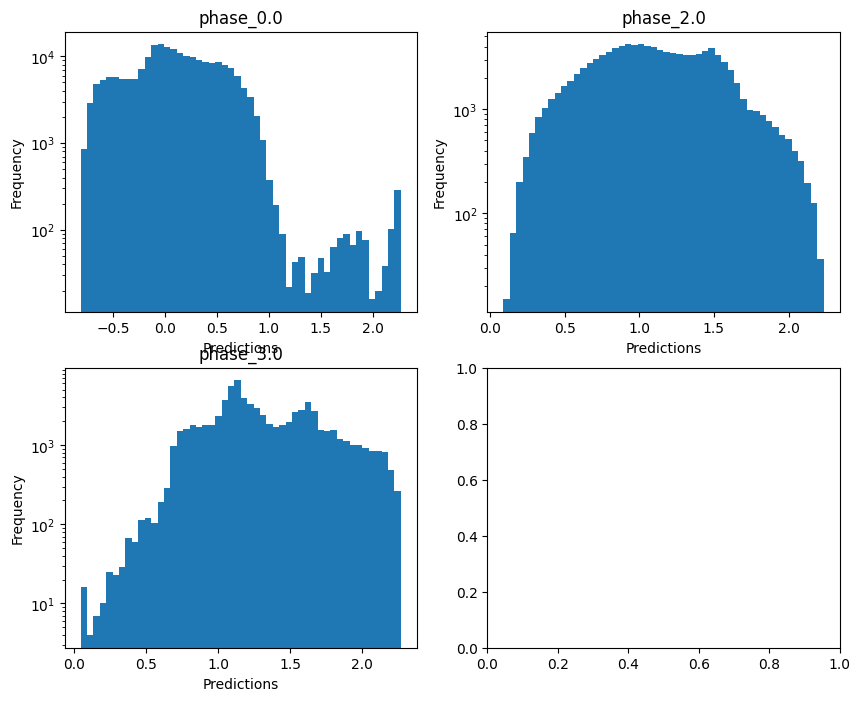

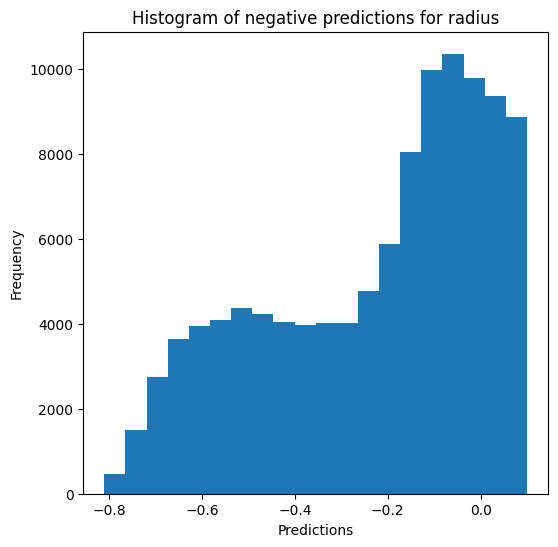

Saving predictions and results...


In [20]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [21]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997583045951958
  RMSE :  0.051233149447974365
  MAE :  0.016968595171673886
  MedAE :  0.004124785423574195
  CORR :  0.999879147253342
  MAX_ER :  5.116395062787612
  Percentiles : 
    75th percentile :  0.013618599755656824
    90th percentile :  0.04197387756715401
    95th percentile :  0.07400474802007932
    99th percentile :  0.19527535312908875

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999397327291966
  RMSE :  0.02522697977026462
  MAE :  0.007748194890098275
  MedAE :  0.00032497995659408474
  CORR :  0.9999700030723048
  MAX_ER :  1.4104238006648107
  Percentiles : 
    75th percentile :  0.005825818524694187
    90th percentile :  0.023625009870831985
    95th 

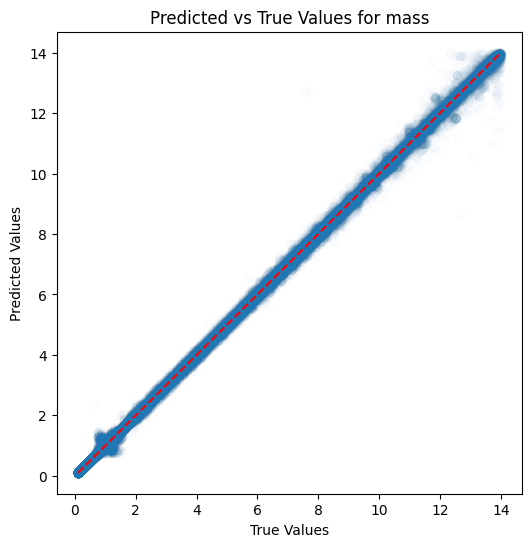

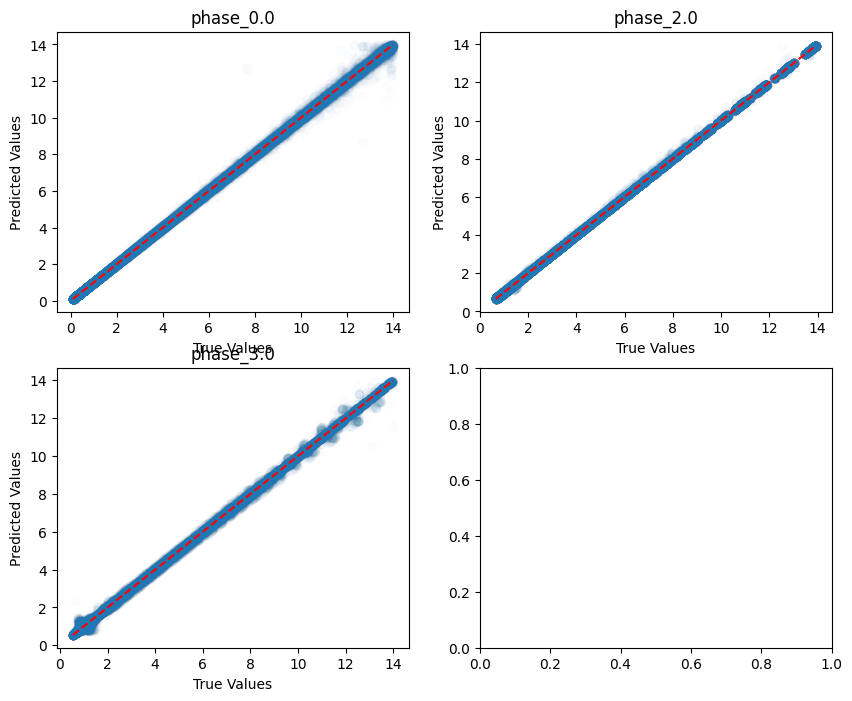

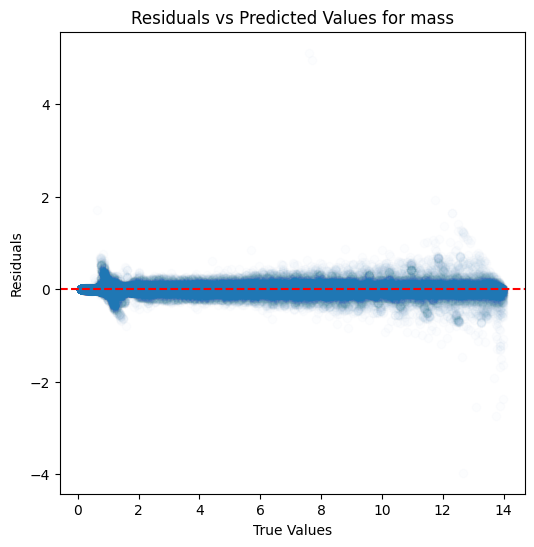

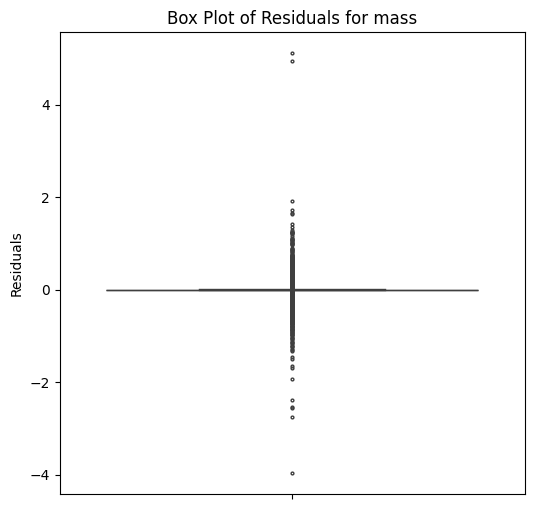

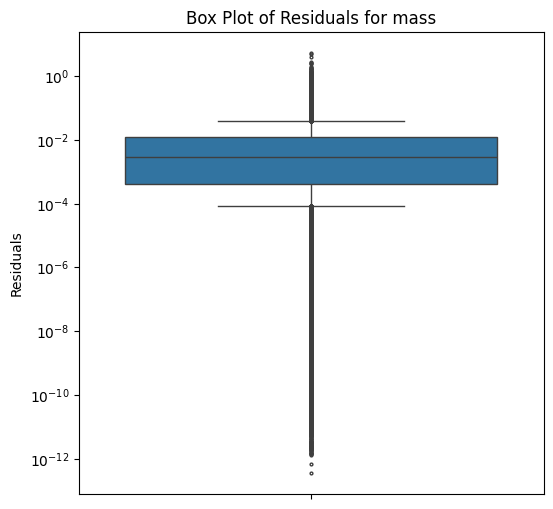

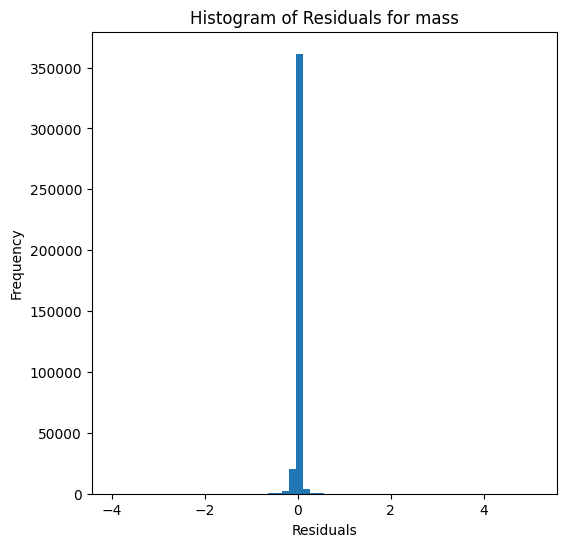

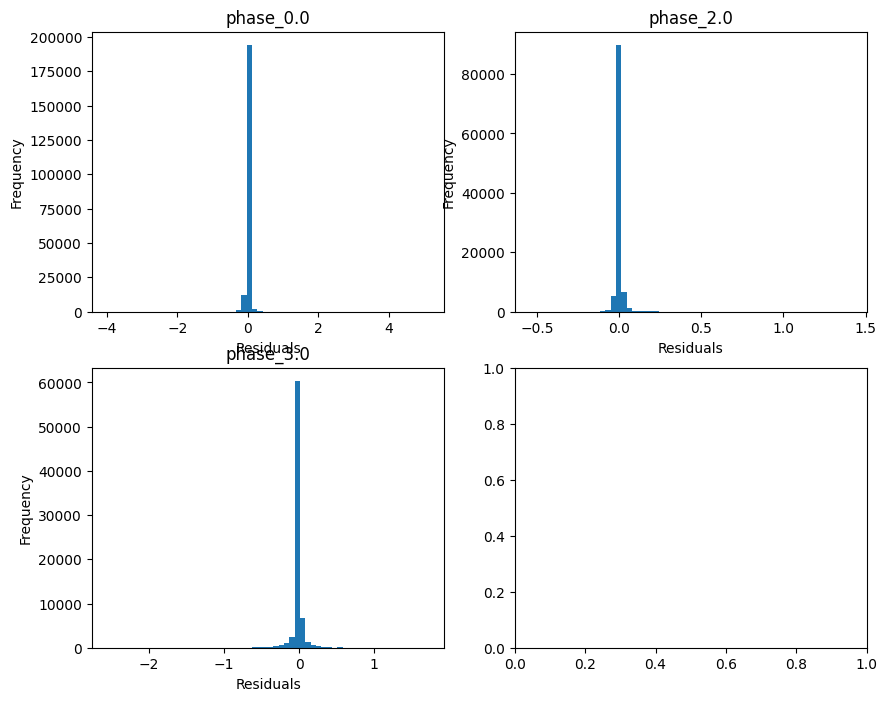

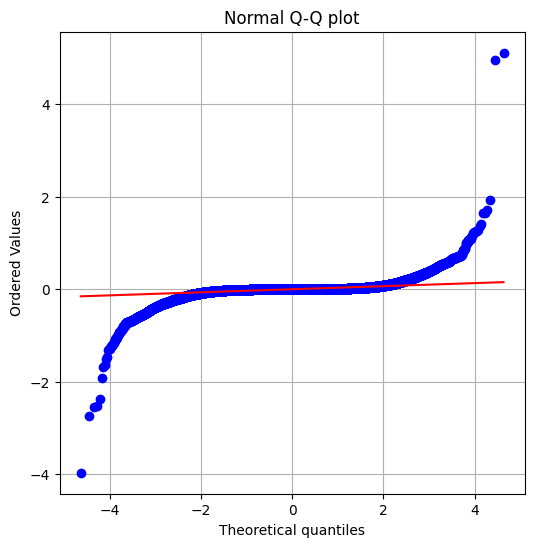

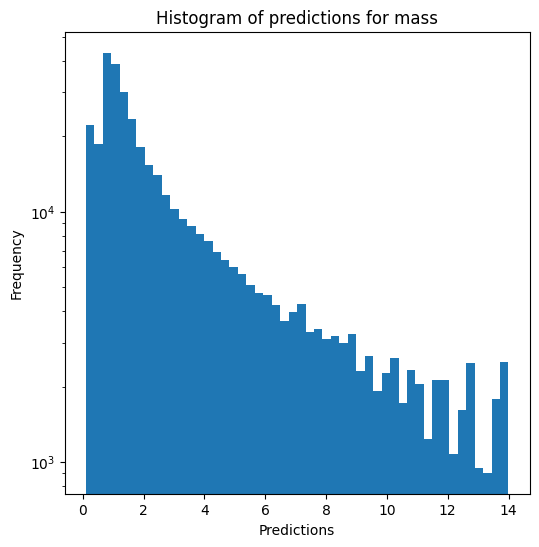

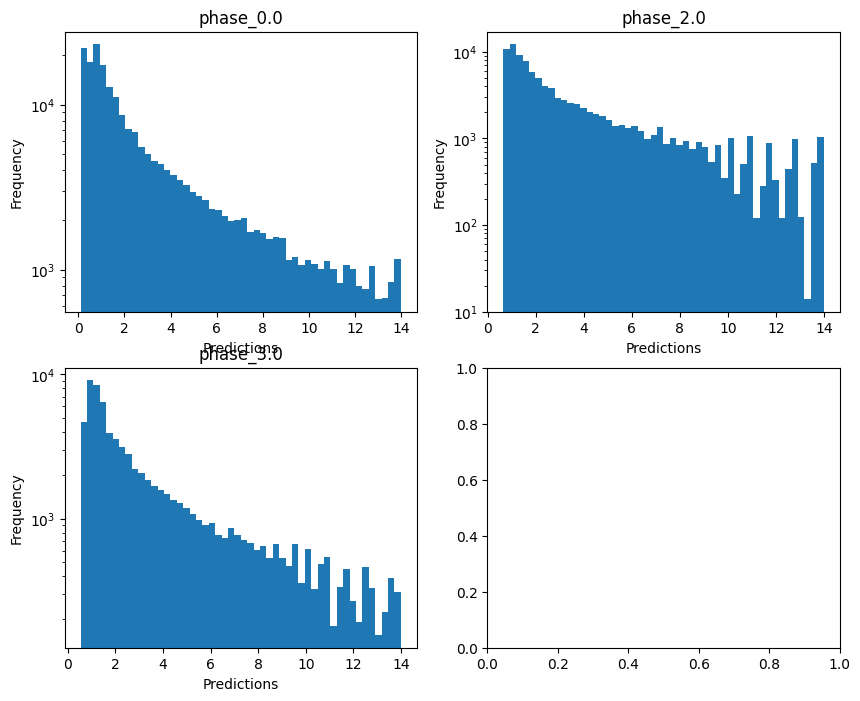

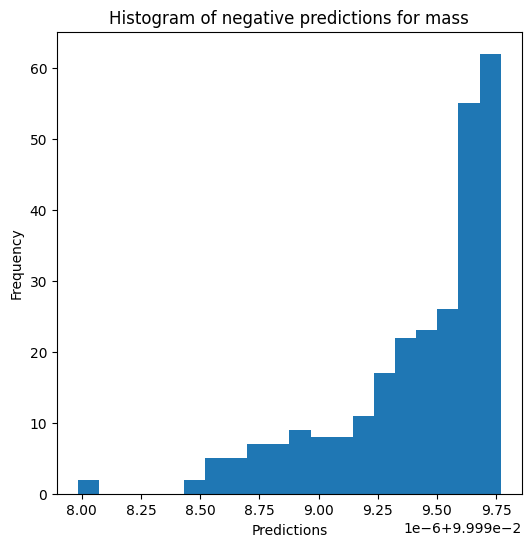


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9997875779948535
  RMSE :  0.006141826504294464
  MAE :  0.003638683956455946
  MedAE :  0.002286502222295095
  CORR :  0.9998937834528678
  MAX_ER :  0.31869682061915194
  Percentiles : 
    75th percentile :  0.004567618502874127
    90th percentile :  0.00803385738724676
    95th percentile :  0.011329267276609767
    99th percentile :  0.023766117231280845

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.999483610040929
  RMSE :  0.010584278968968705
  MAE :  0.007369149628304041
  MedAE :  0.006046346094182087
  CORR :  0.999743071015114
  MAX_ER :  0.445657670892194
  Percentiles : 
    75th percentile :  0.009832366156564465
    90th percentile :  0.013866767028991879
    95th percentile :  0.01727854799964939
    99th percentile :  0.03214962192000819

radius results for the p

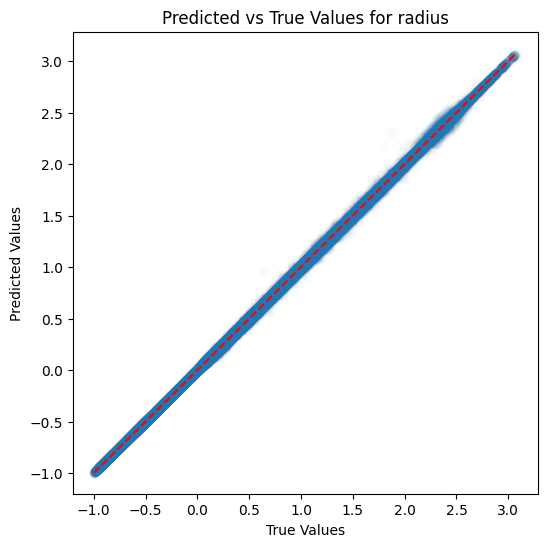

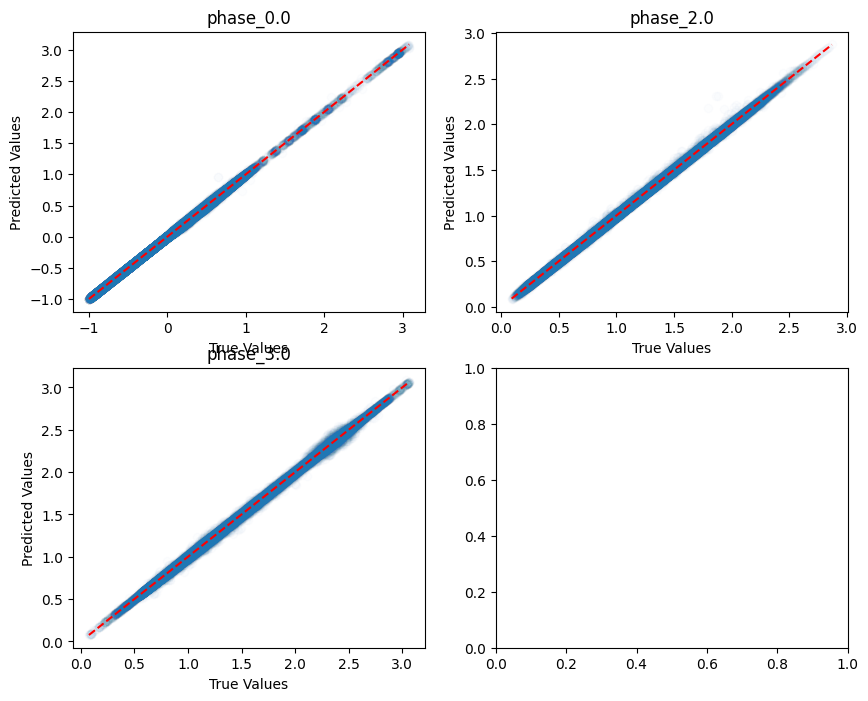

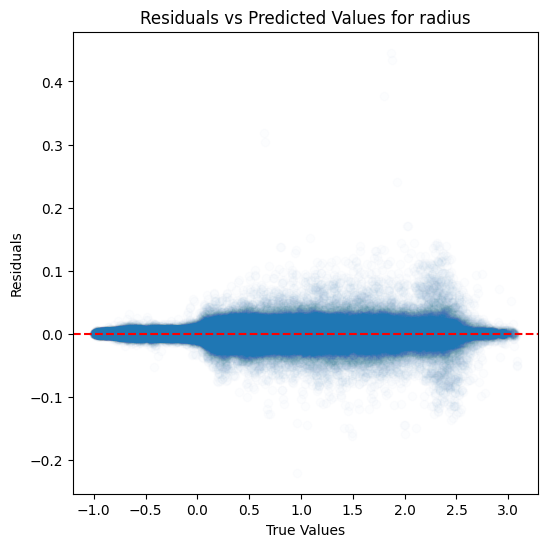

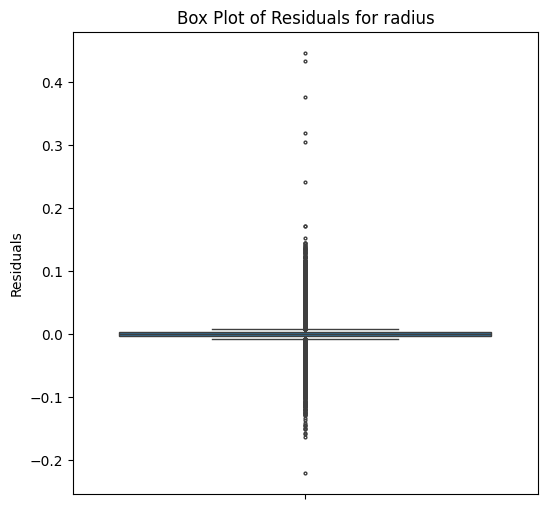

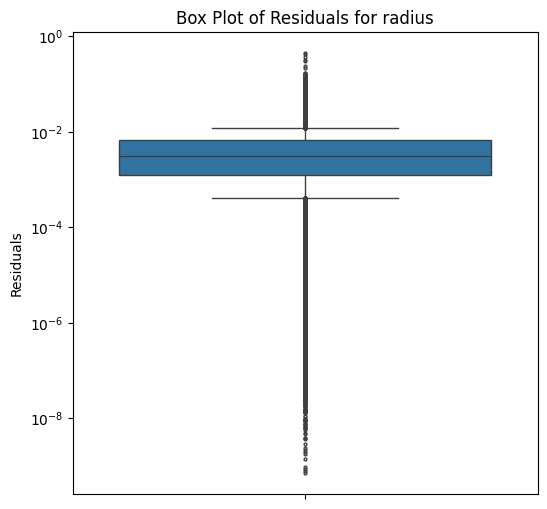

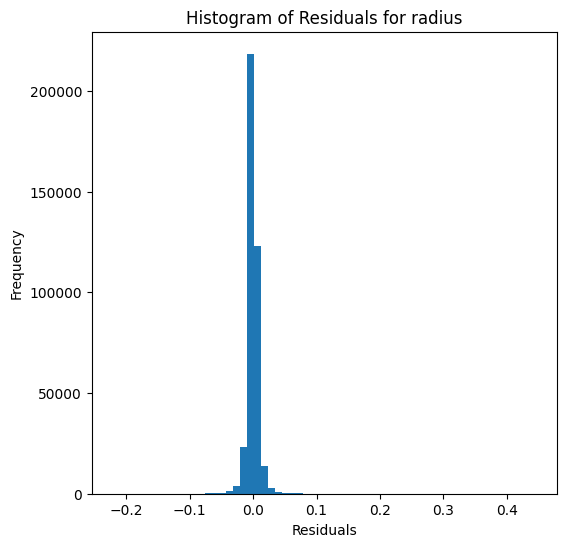

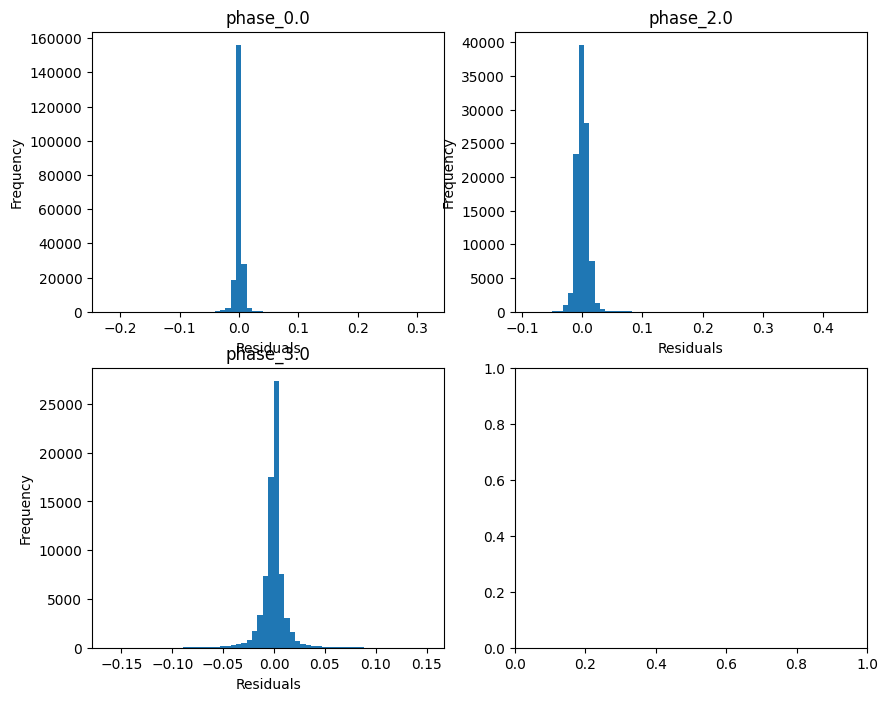

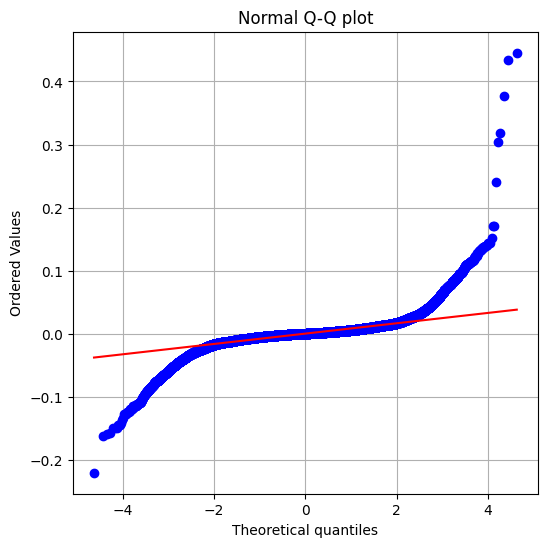

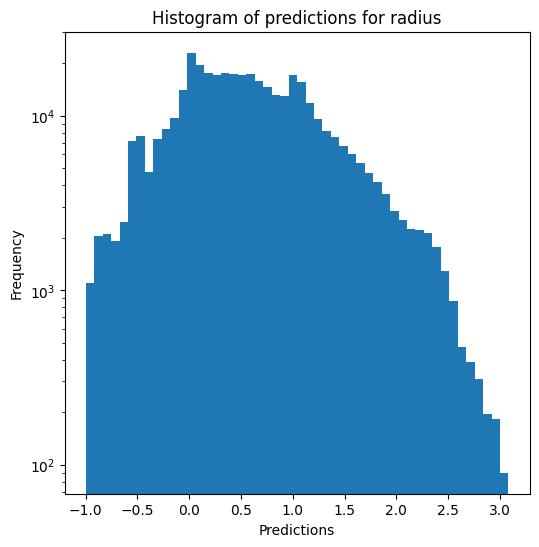

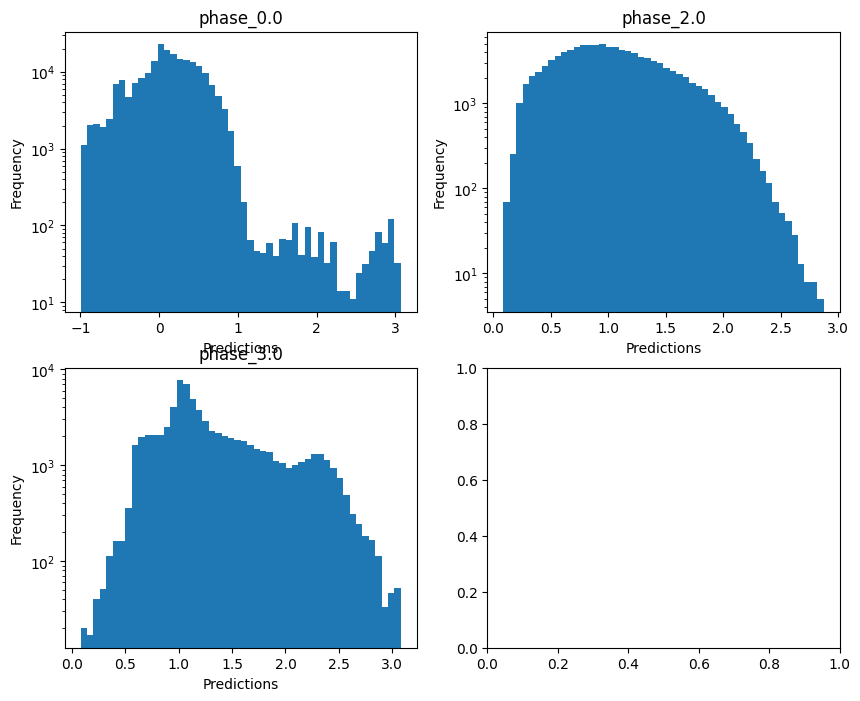

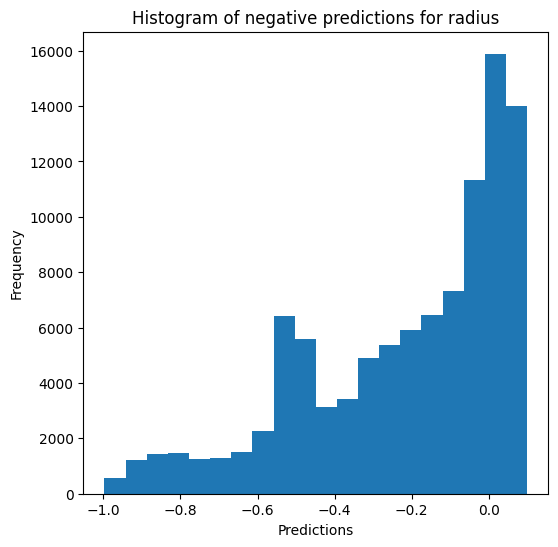

Saving predictions and results...


In [22]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [23]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997486144426394
  RMSE :  0.052261521113049214
  MAE :  0.017688589967628652
  MedAE :  0.004879810286938069
  CORR :  0.9998743020897197
  MAX_ER :  2.0795444002815096
  Percentiles : 
    75th percentile :  0.015260573193404792
    90th percentile :  0.03999977324014134
    95th percentile :  0.06974368124167593
    99th percentile :  0.20389945990901717

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997623765689257
  RMSE :  0.050029969096818915
  MAE :  0.018579920703088938
  MedAE :  0.002444834219493708
  CORR :  0.9998811844058508
  MAX_ER :  1.0231575084287226
  Percentiles : 
    75th percentile :  0.013625724010325913
    90th percentile :  0.05227134

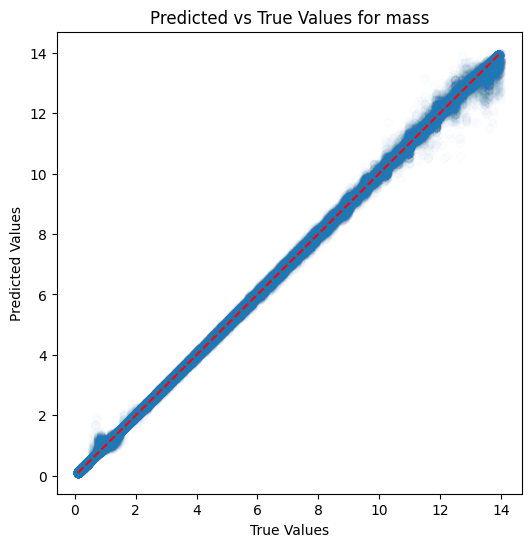

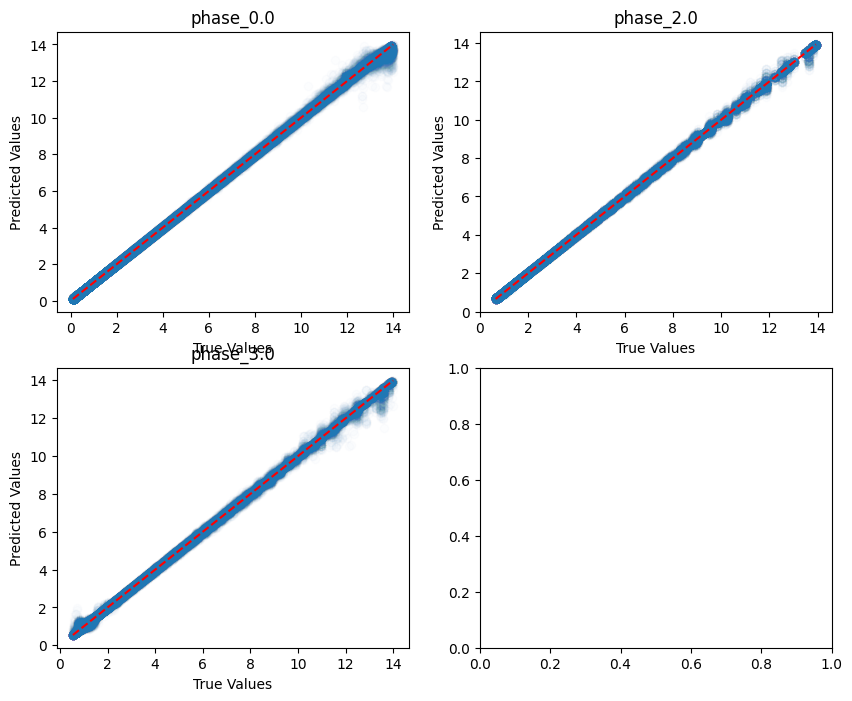

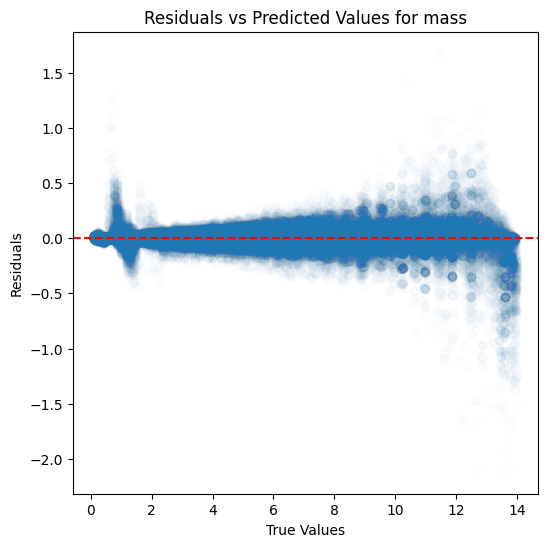

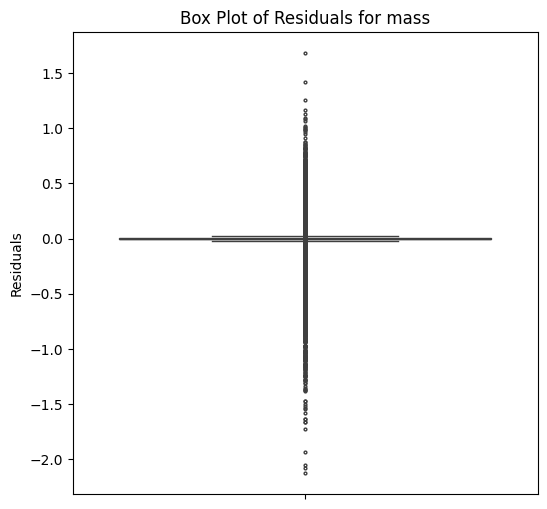

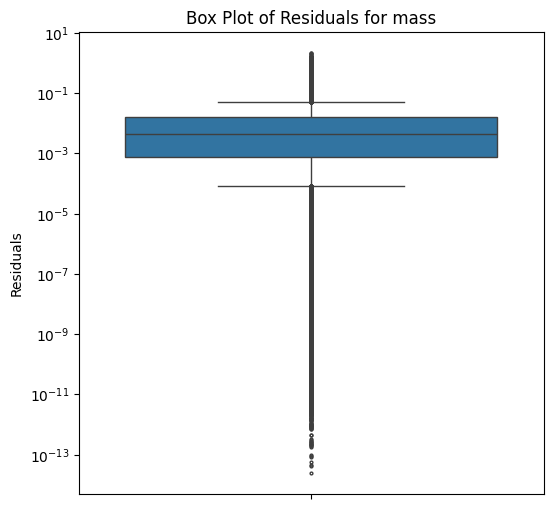

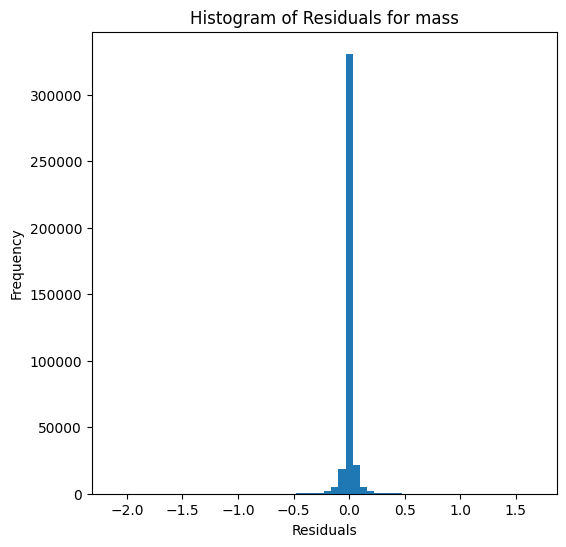

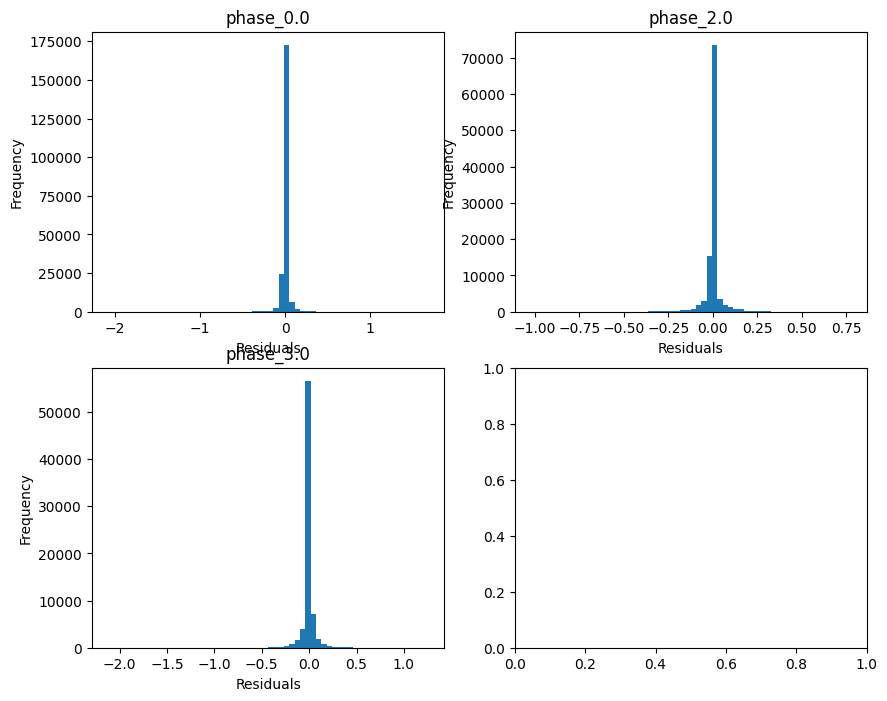

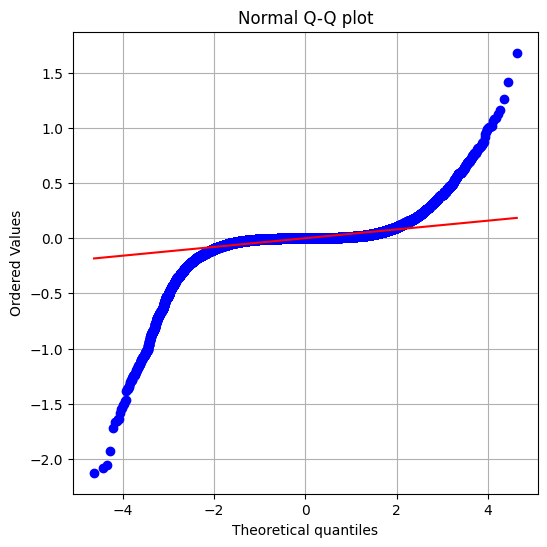

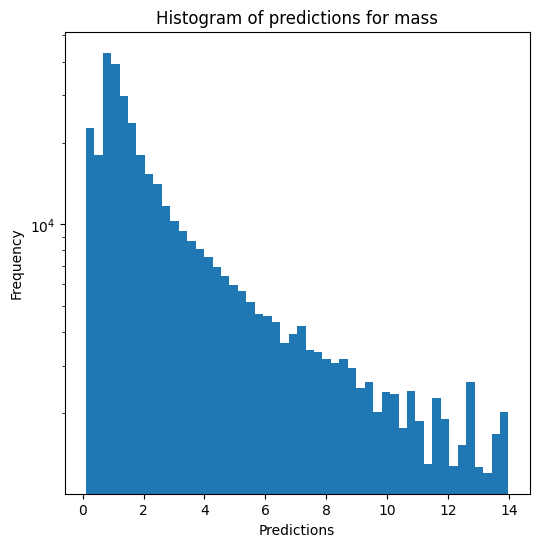

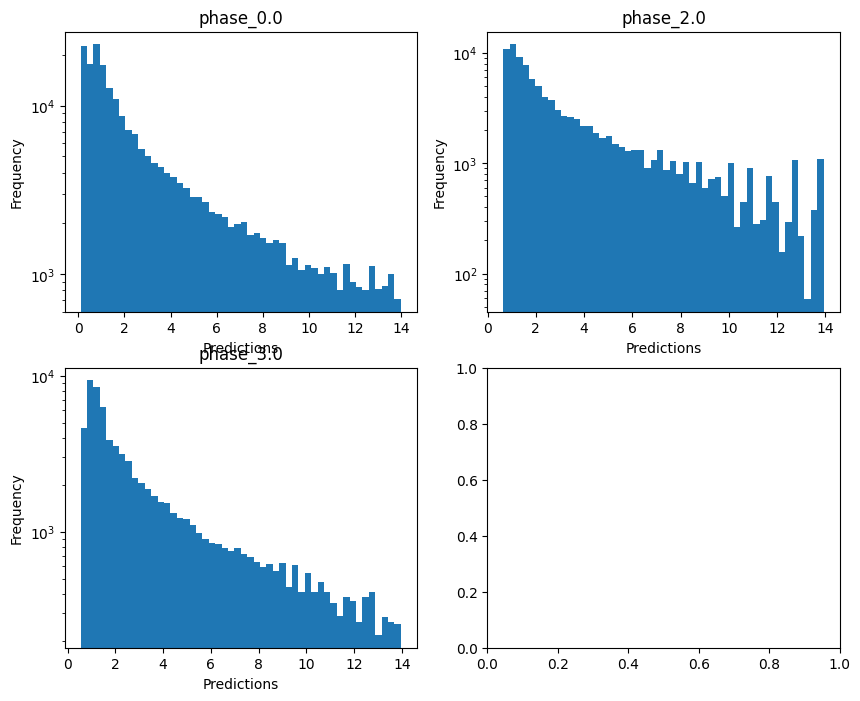


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9998294223596507
  RMSE :  0.005503419824447745
  MAE :  0.002943889163354718
  MedAE :  0.0016851544574350563
  CORR :  0.9999147965205015
  MAX_ER :  0.1469276230745531
  Percentiles : 
    75th percentile :  0.0033353905323522115
    90th percentile :  0.006362677061543809
    95th percentile :  0.00936940613261865
    99th percentile :  0.023354637681837976

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9996587568576741
  RMSE :  0.008704832176843912
  MAE :  0.006013842587106984
  MedAE :  0.004282330593719852
  CORR :  0.9998373852373217
  MAX_ER :  0.1442203873836605
  Percentiles : 
    75th percentile :  0.007936927361861301
    90th percentile :  0.012970351099553195
    95th percentile :  0.0169735189010989
    99th percentile :  0.028783957768348856

radius results for t

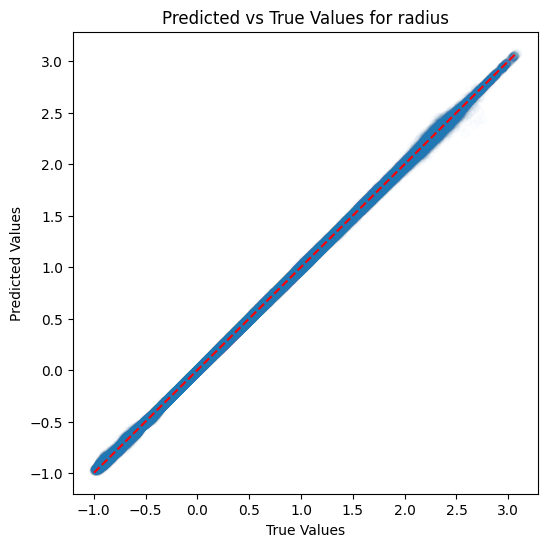

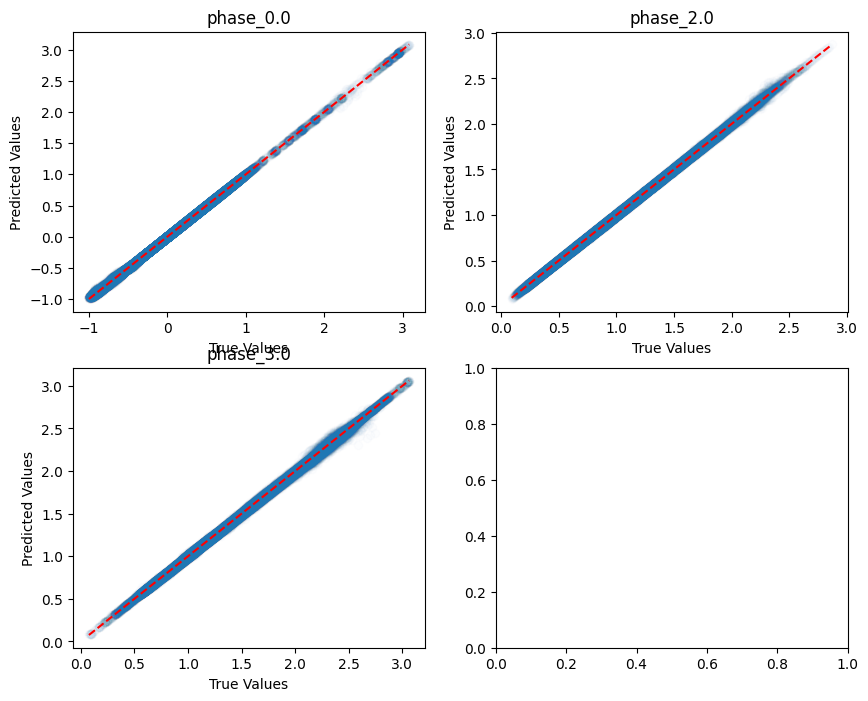

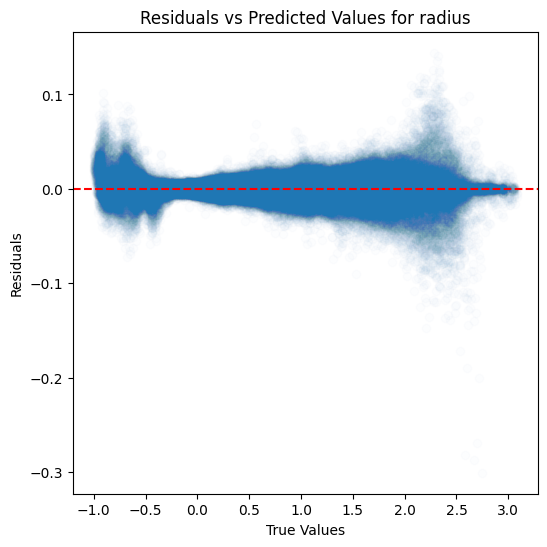

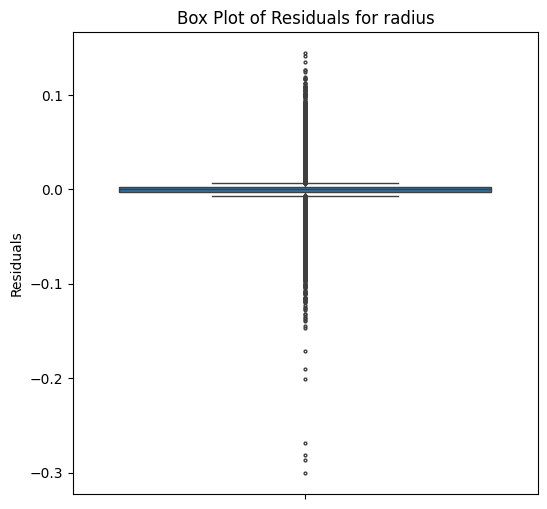

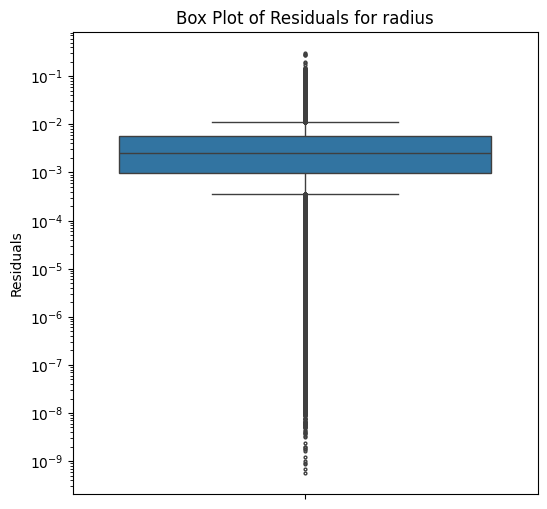

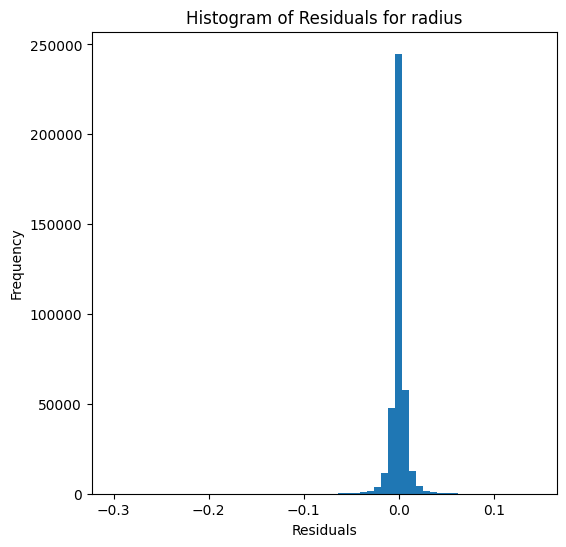

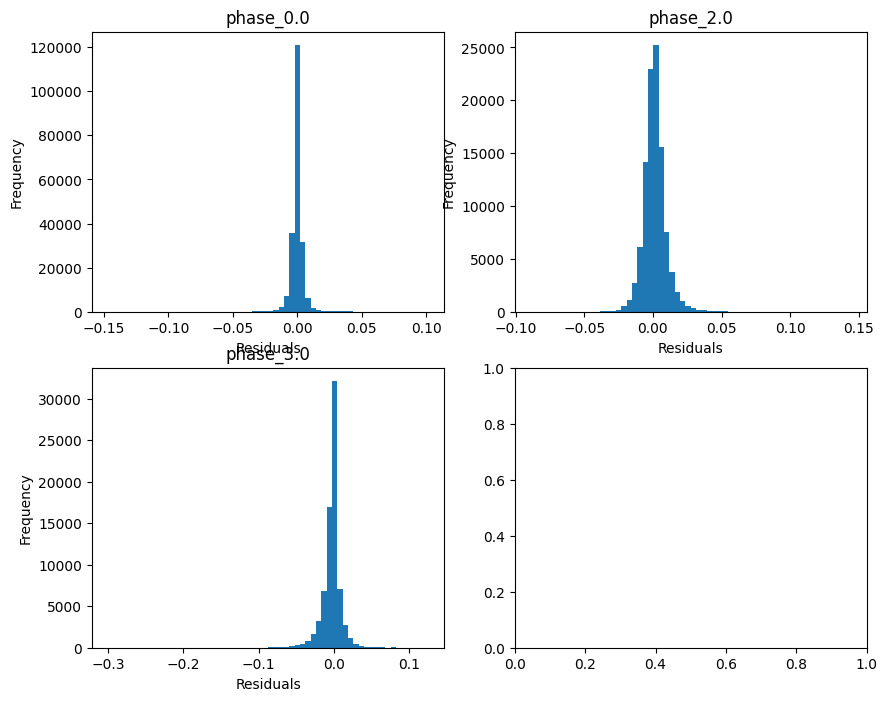

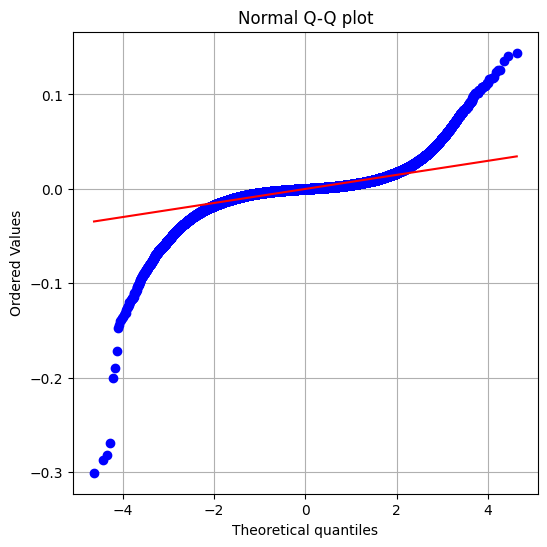

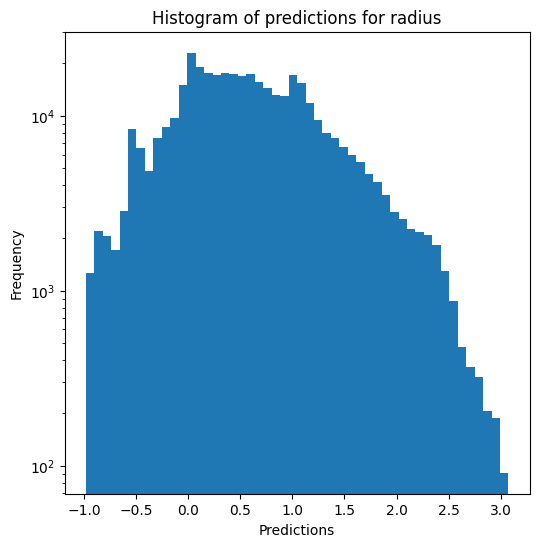

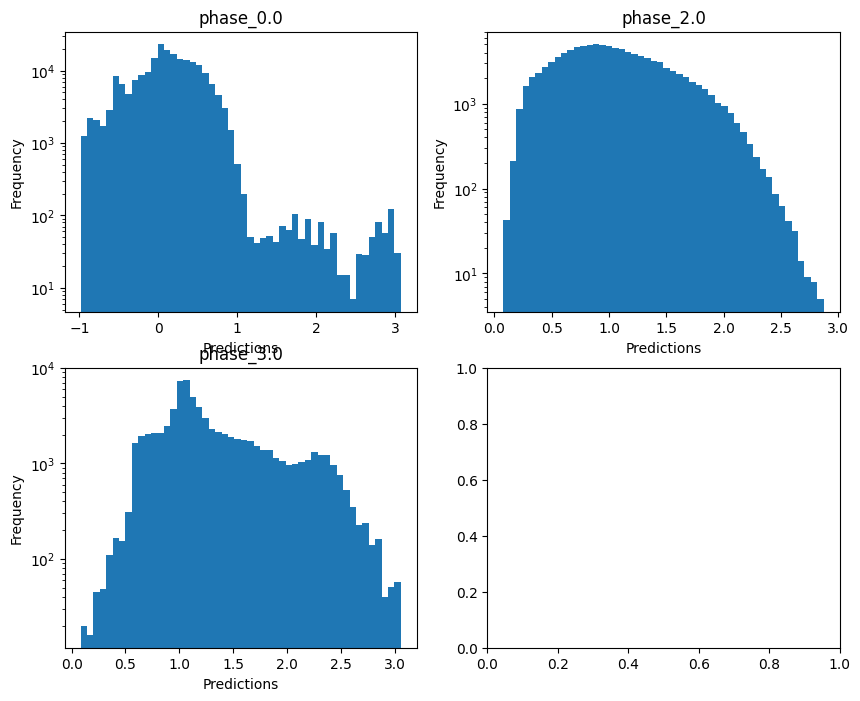

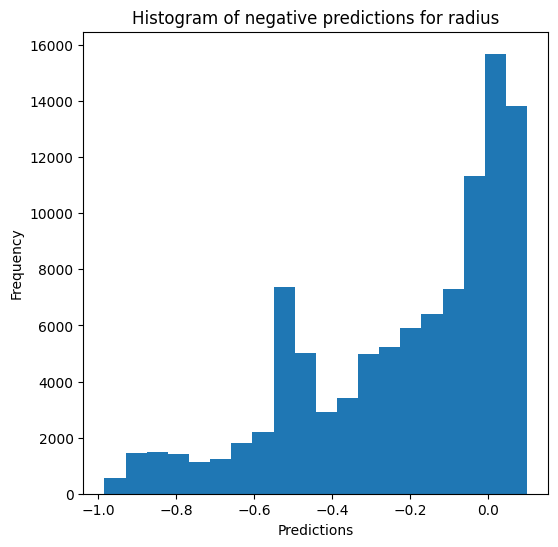

Saving predictions and results...


In [24]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [25]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.999920865422017
  RMSE :  0.02931763361186024
  MAE :  0.008900185801452189
  MedAE :  0.002466203699487579
  CORR :  0.9999604340356466
  MAX_ER :  2.3179695739491795
  Percentiles : 
    75th percentile :  0.00721928036899977
    90th percentile :  0.019710236501539677
    95th percentile :  0.03508250460227469
    99th percentile :  0.10335769940118199

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999735428878901
  RMSE :  0.016803551278193052
  MAE :  0.008458655080863967
  MedAE :  0.004356526312045084
  CORR :  0.9999869305377866
  MAX_ER :  0.5654557981448196
  Percentiles : 
    75th percentile :  0.01013328161894636
    90th percentile :  0.0190538093168926
    95th perc

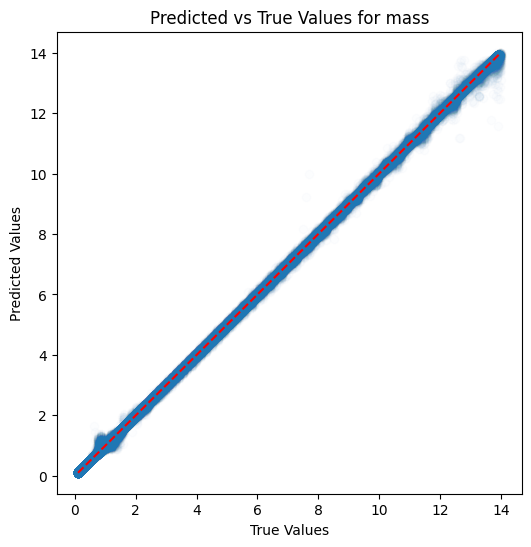

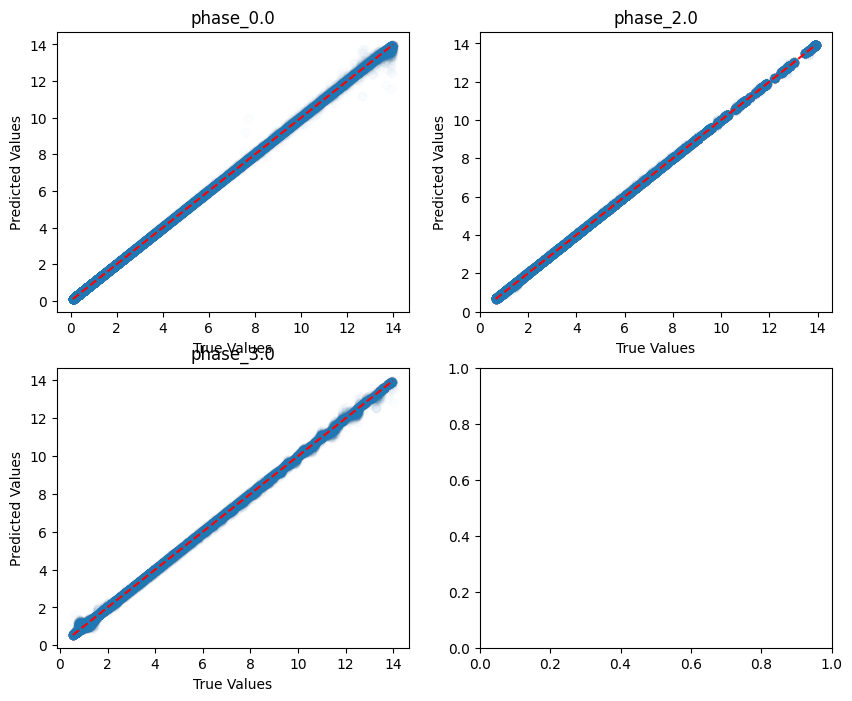

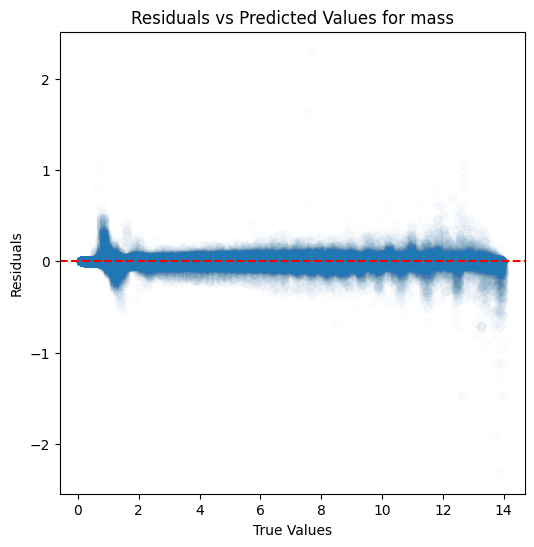

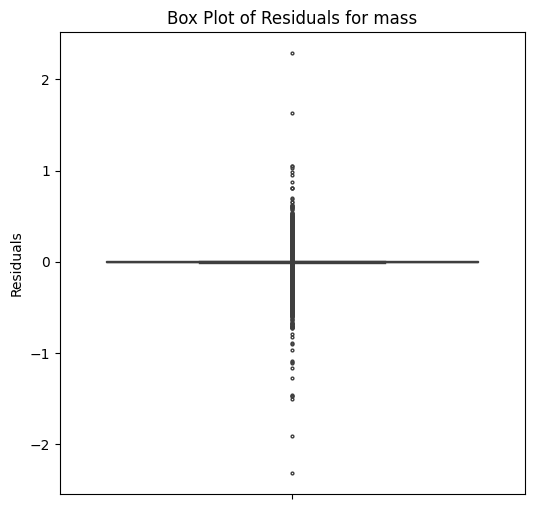

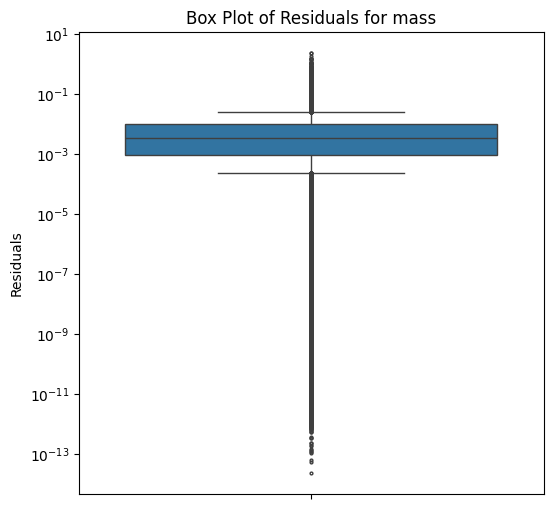

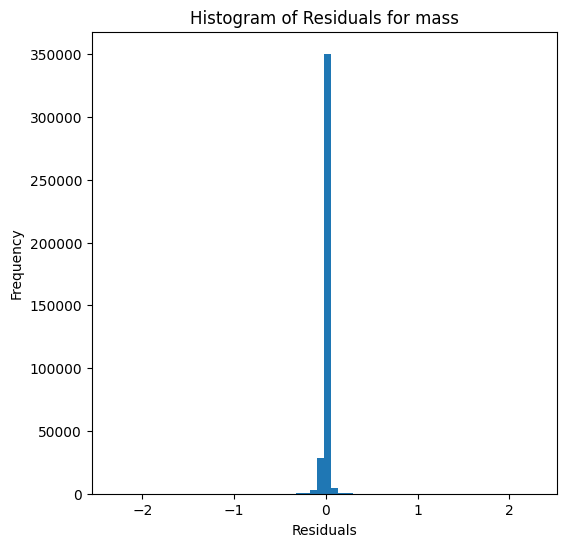

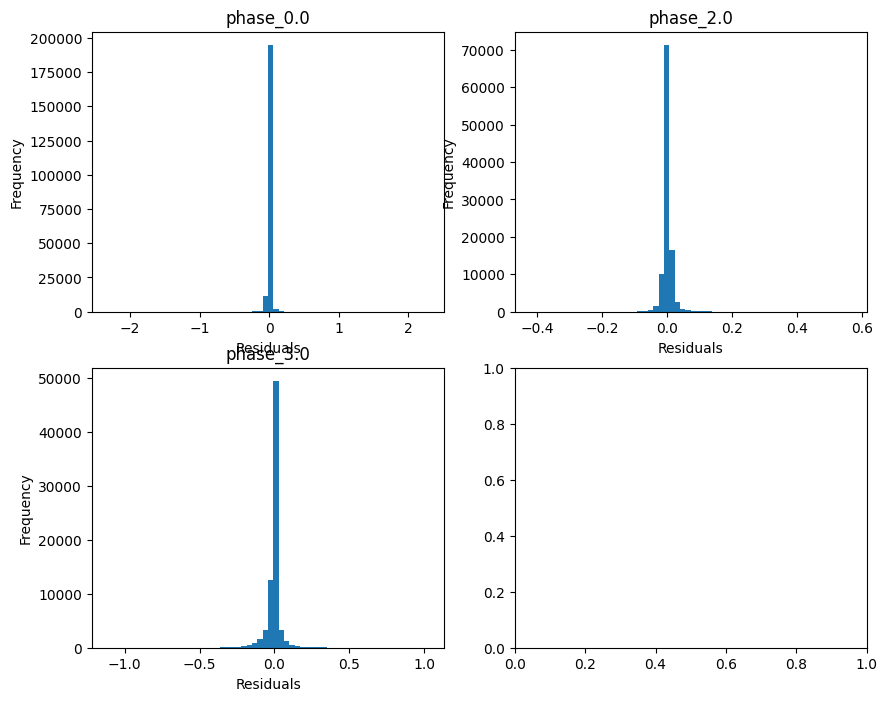

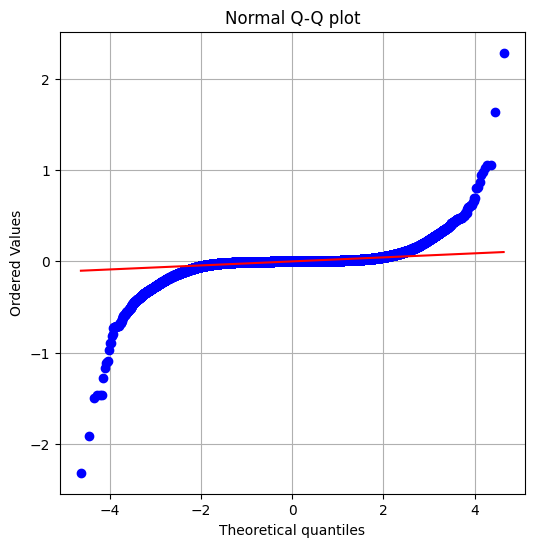

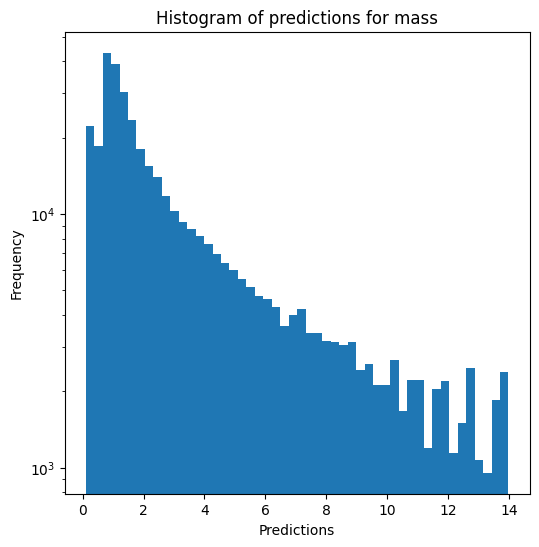

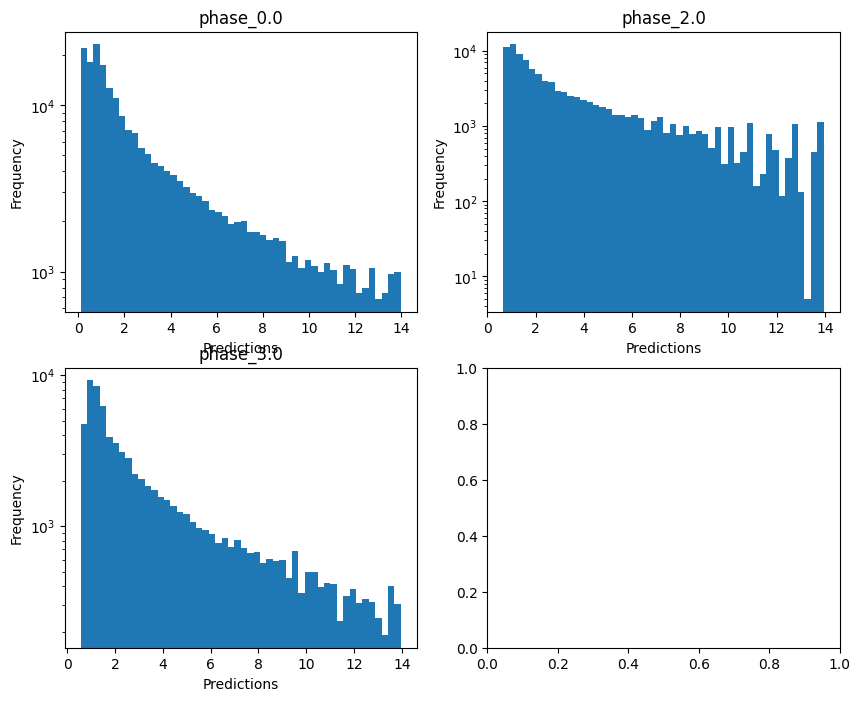

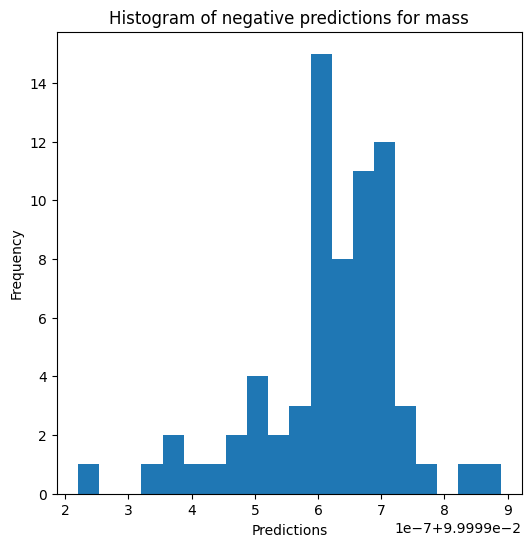


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999525398119077
  RMSE :  0.002904800841132242
  MAE :  0.0016383491820489515
  MedAE :  0.0009035073986896069
  CORR :  0.9999762783161761
  MAX_ER :  0.144037471170677
  Percentiles : 
    75th percentile :  0.001953142651846096
    90th percentile :  0.003815991817835591
    95th percentile :  0.0056277543182541735
    99th percentile :  0.011386537586641635

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9999190776430146
  RMSE :  0.00422883214023608
  MAE :  0.0029293085876678495
  MedAE :  0.0020295907604959695
  CORR :  0.9999604064873542
  MAX_ER :  0.0542101401369699
  Percentiles : 
    75th percentile :  0.0039619207247854615
    90th percentile :  0.006604384021848809
    95th percentile :  0.008684329207123176
    99th percentile :  0.014126848994735125

radius results 

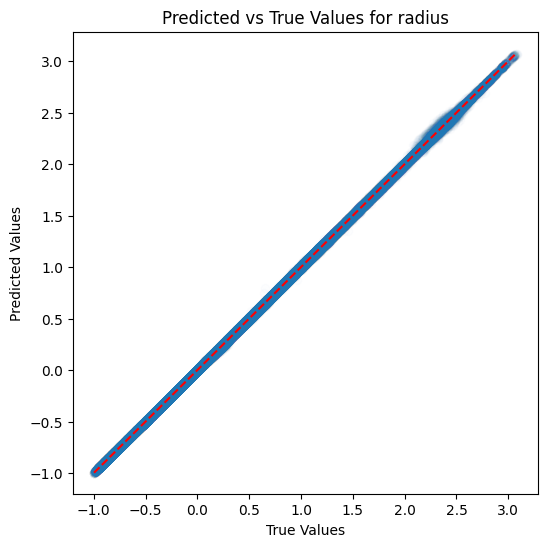

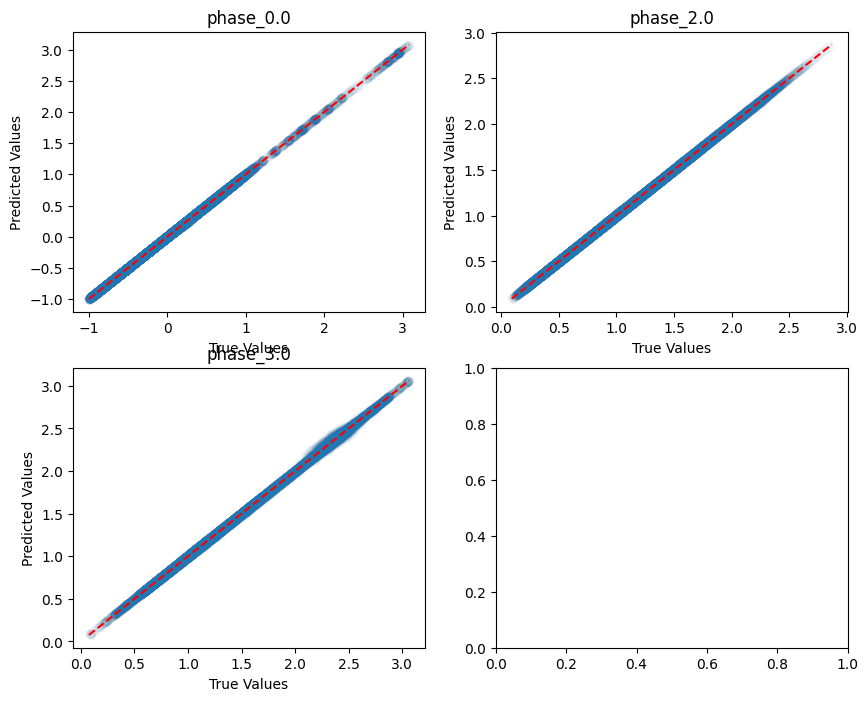

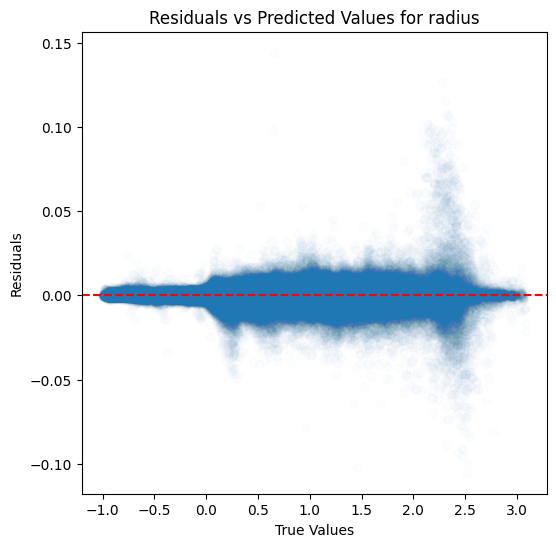

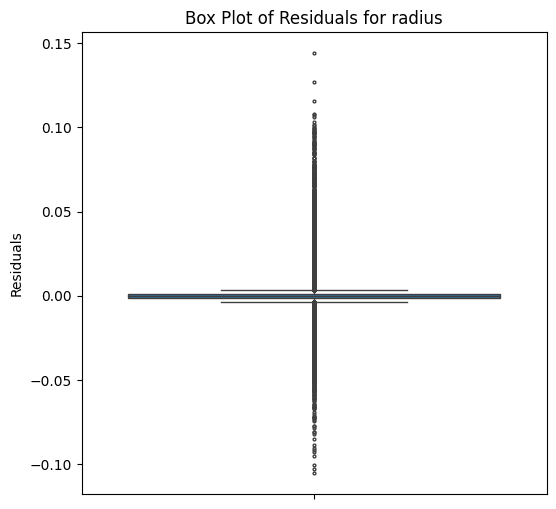

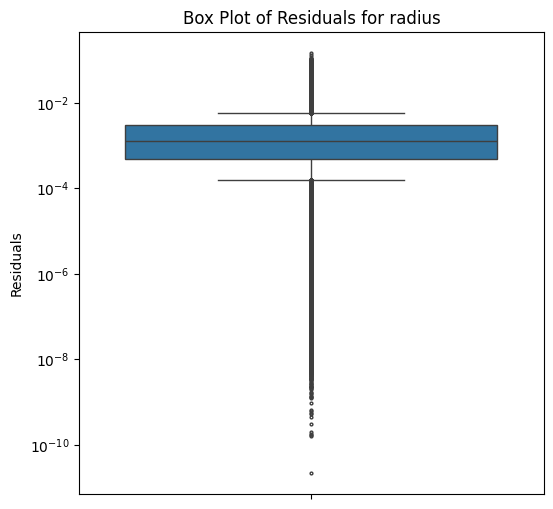

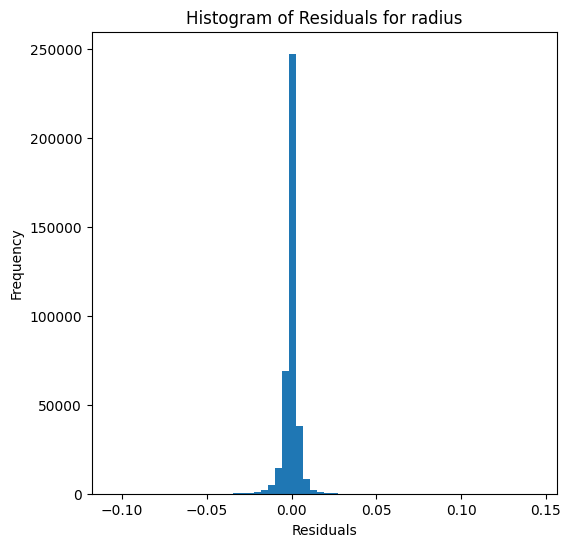

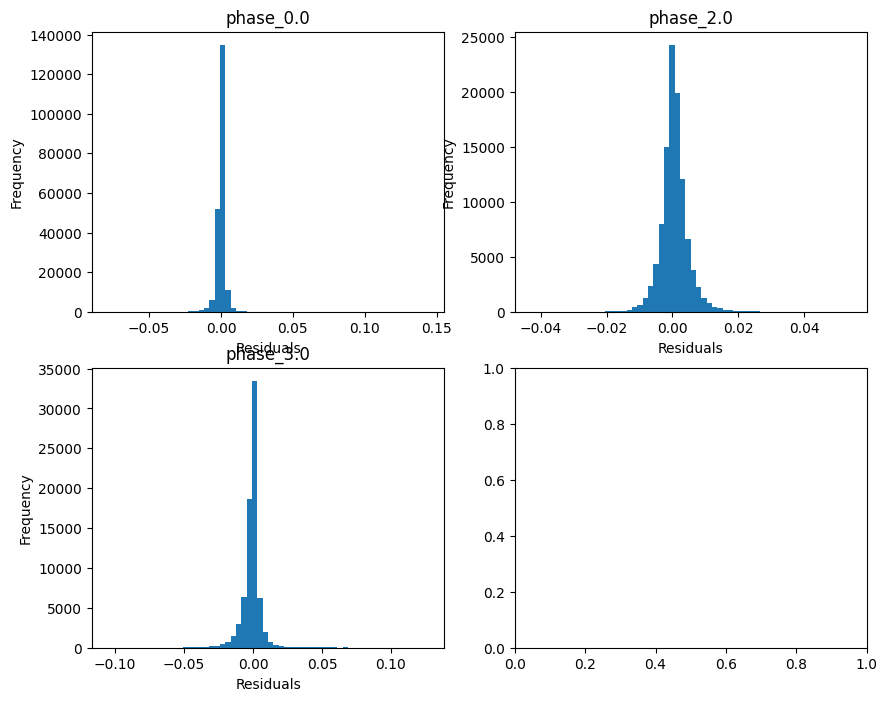

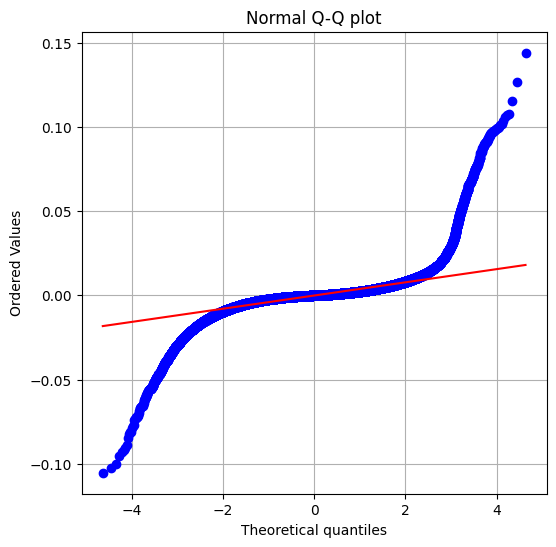

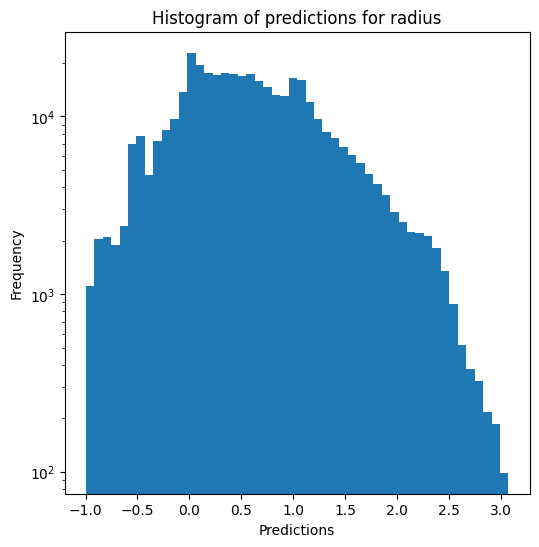

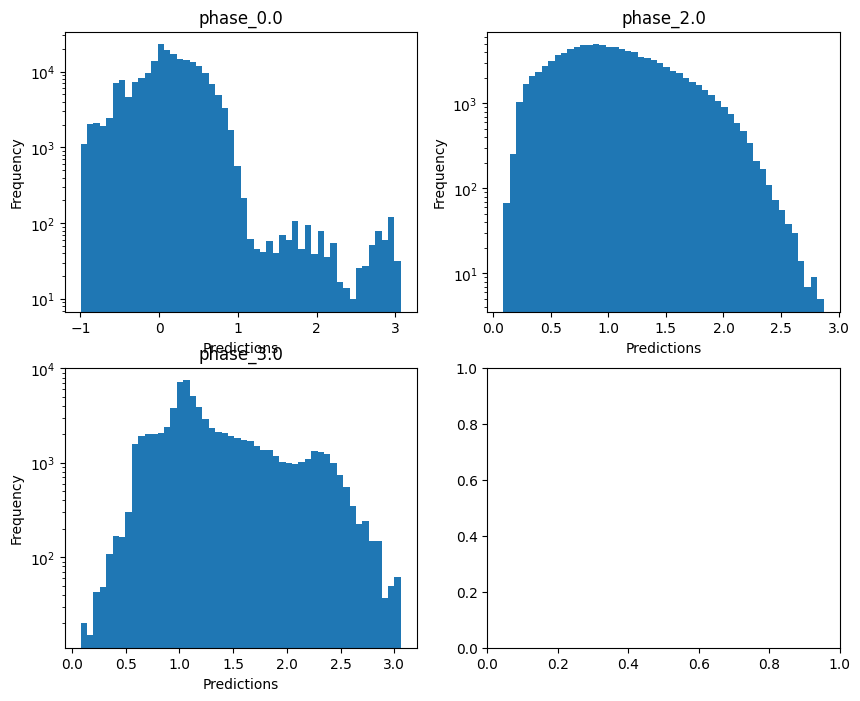

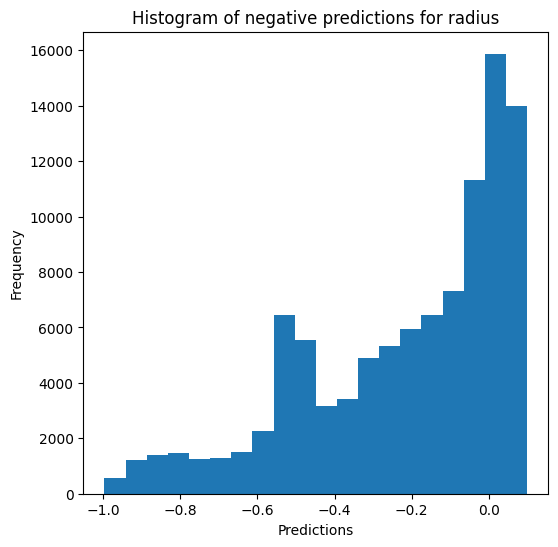

Saving predictions and results...


In [26]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [27]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9987831543310836
  RMSE :  0.1149590910631718
  MAE :  0.06418533107403708
  MedAE :  0.0318581656326824
  CORR :  0.9993914723207802
  MAX_ER :  2.0163527255375087
  Percentiles : 
    75th percentile :  0.07721646362022927
    90th percentile :  0.15668409319234086
    95th percentile :  0.2307016871593781
    99th percentile :  0.45677135586287154

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997595692186471
  RMSE :  0.052205170934861655
  MAE :  0.0358470691685197
  MedAE :  0.0236489414037091
  CORR :  0.9998855210027342
  MAX_ER :  0.8272298737301256
  Percentiles : 
    75th percentile :  0.04856580565273122
    90th percentile :  0.08335999217414161
    95th percentile :

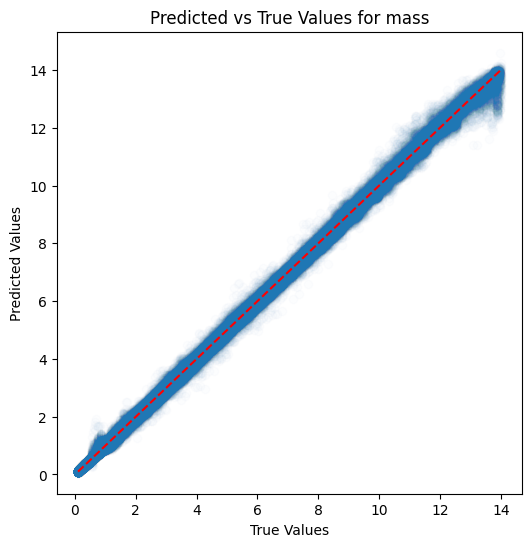

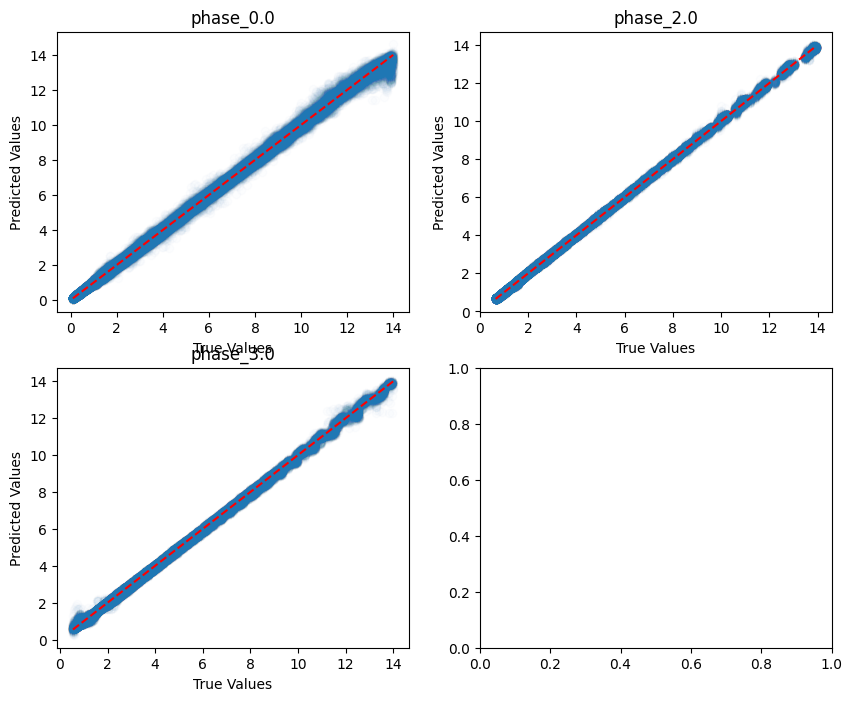

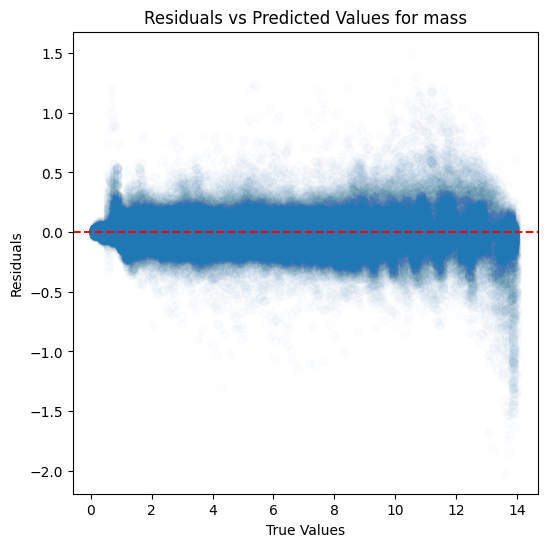

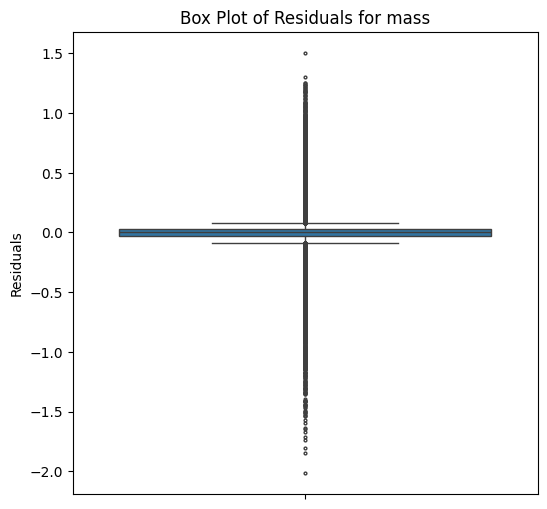

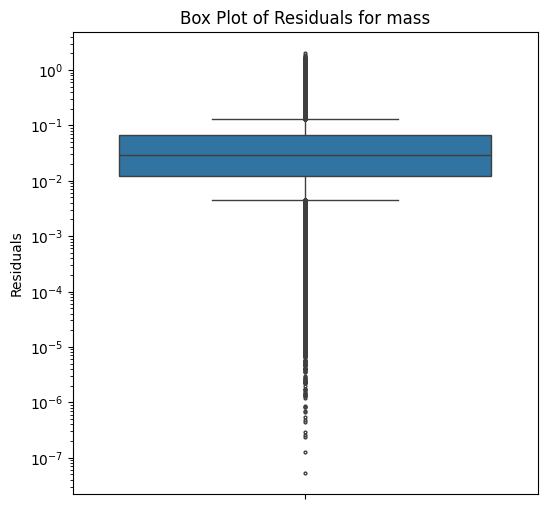

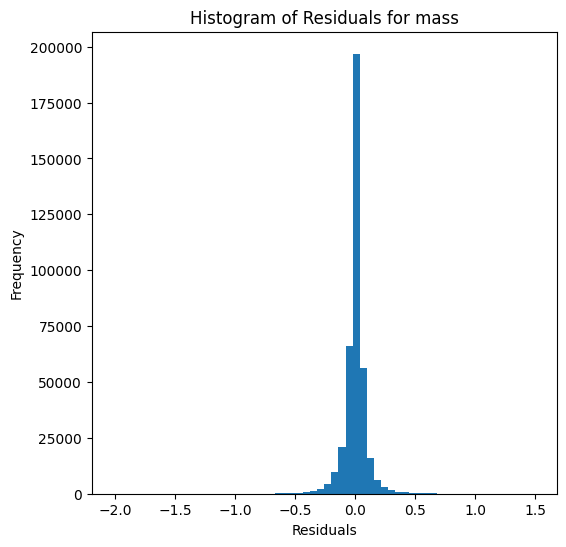

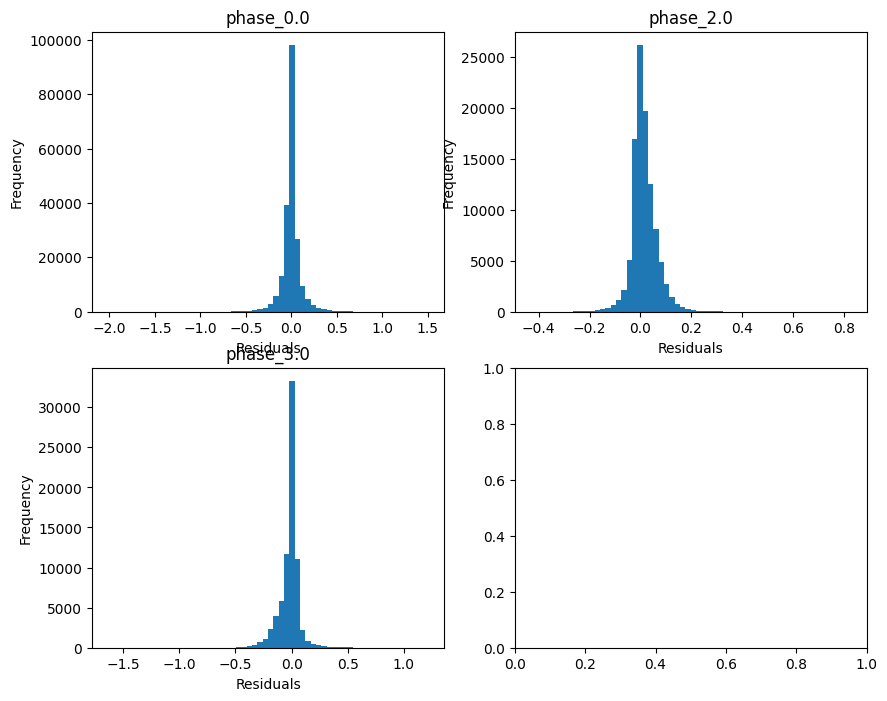

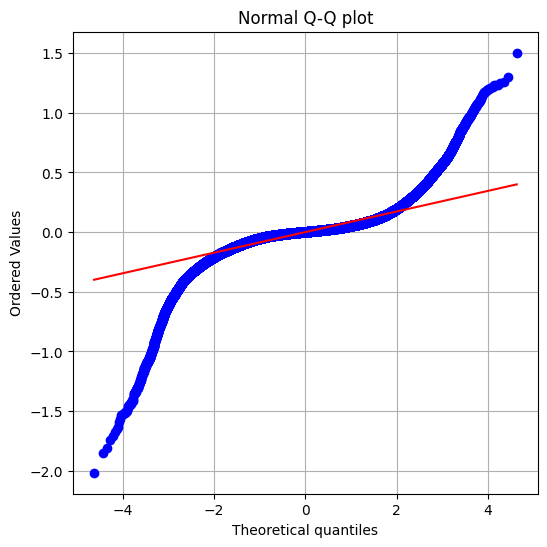

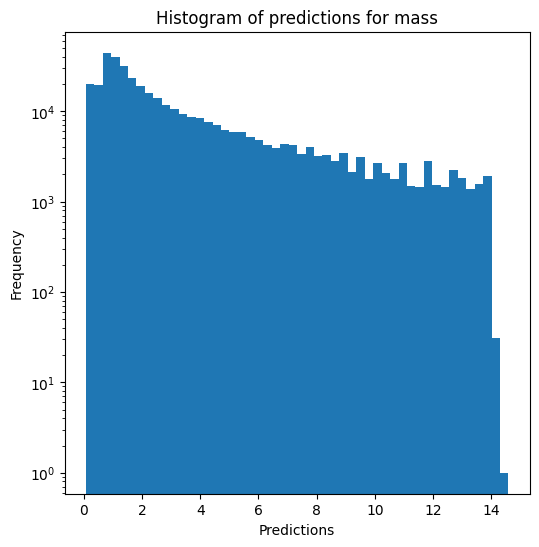

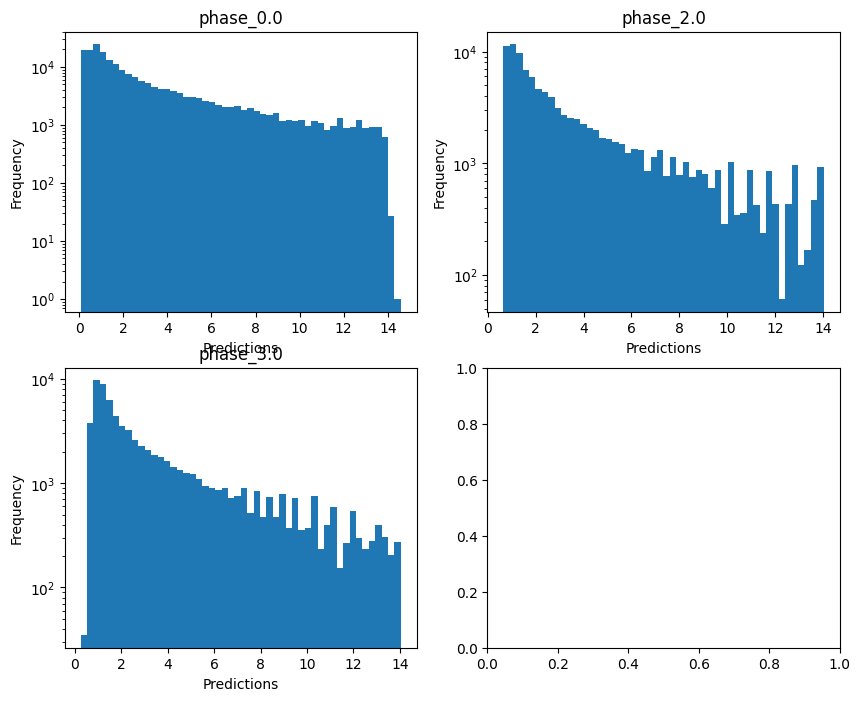

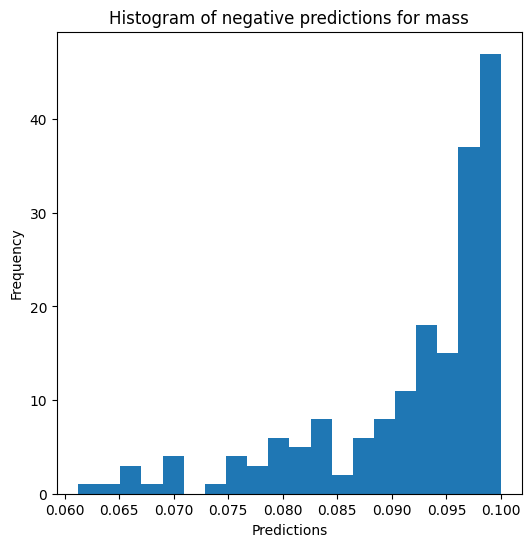


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9995023813713967
  RMSE :  0.009397489730325639
  MAE :  0.007154682076098698
  MedAE :  0.005618723184971489
  CORR :  0.99975117658321
  MAX_ER :  0.06197914740156696
  Percentiles : 
    75th percentile :  0.010002913532262306
    90th percentile :  0.015315586455306058
    95th percentile :  0.019229380718413822
    99th percentile :  0.02753318789716734

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9994242378722862
  RMSE :  0.01120082097415677
  MAE :  0.008708090948749086
  MedAE :  0.007066183979173912
  CORR :  0.9997124368361686
  MAX_ER :  0.07004839451298372
  Percentiles : 
    75th percentile :  0.012333964946195514
    90th percentile :  0.018364527765827886
    95th percentile :  0.02245500474611534
    99th percentile :  0.031269862558766084

radius results for the

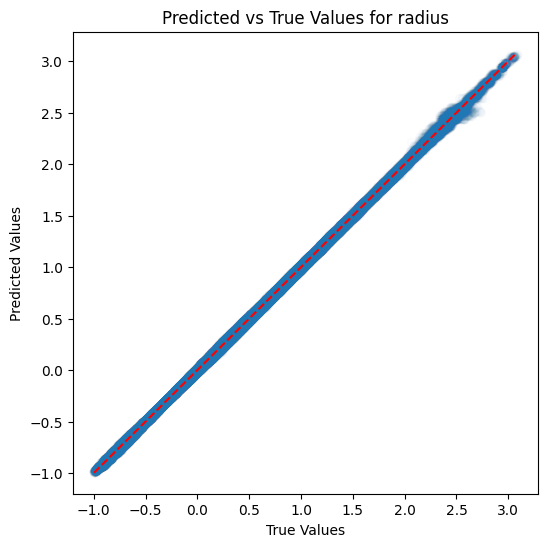

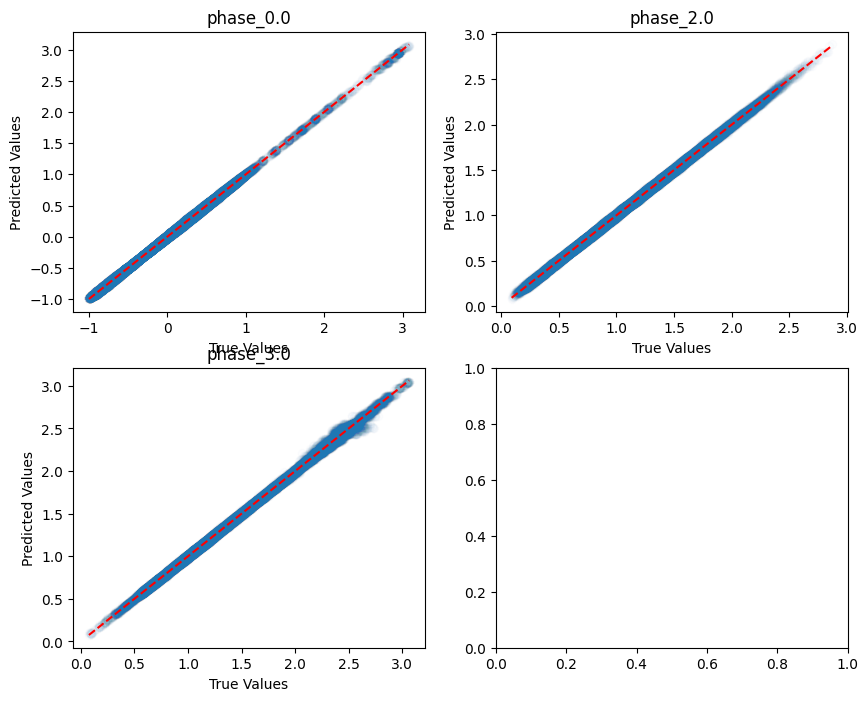

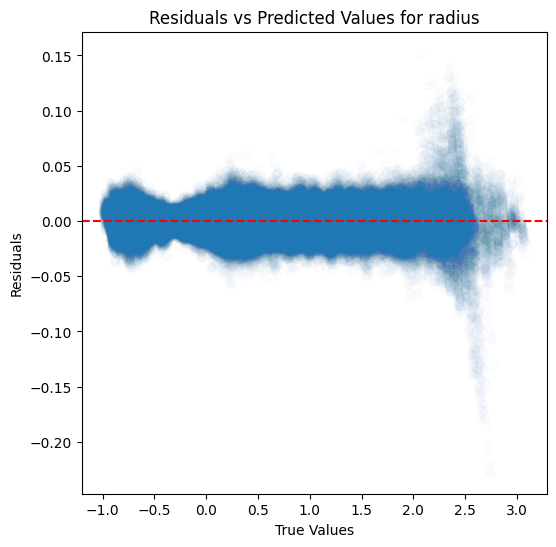

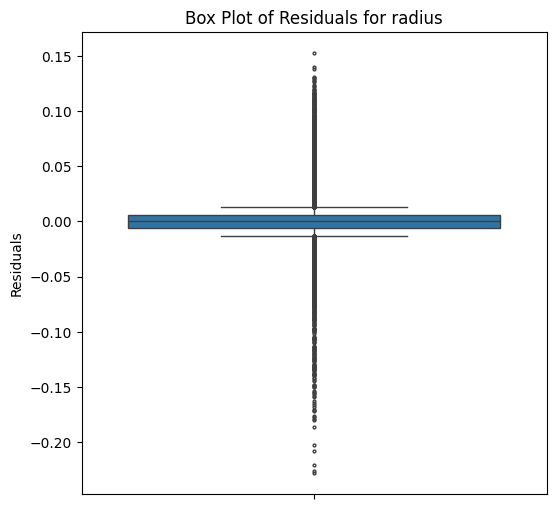

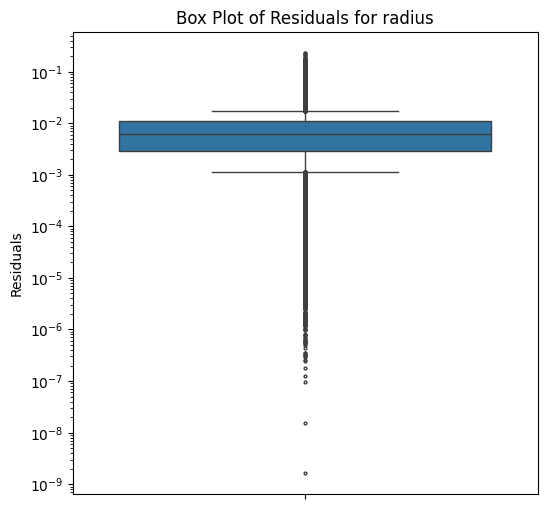

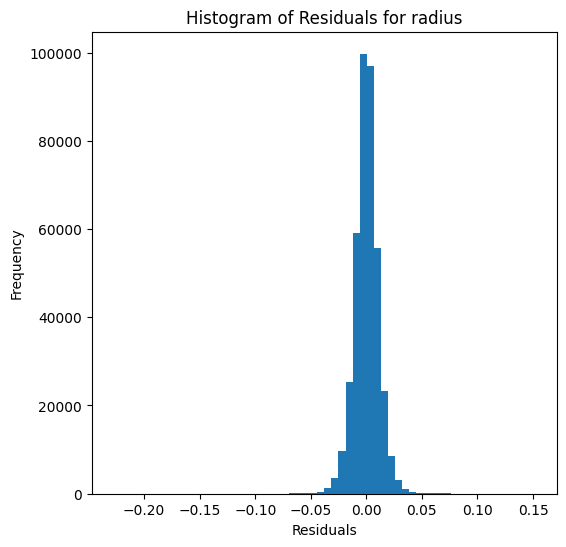

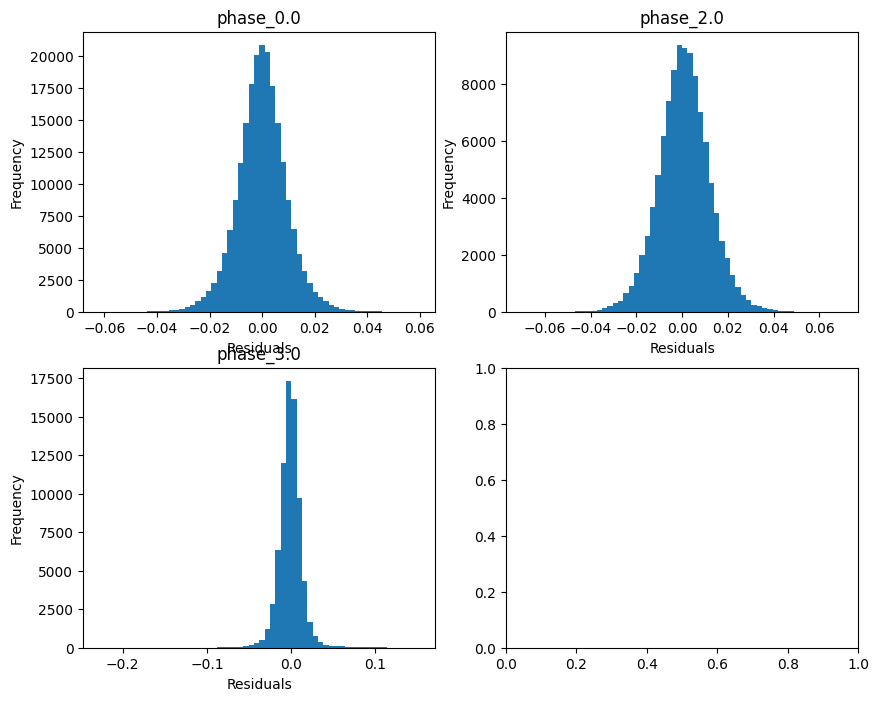

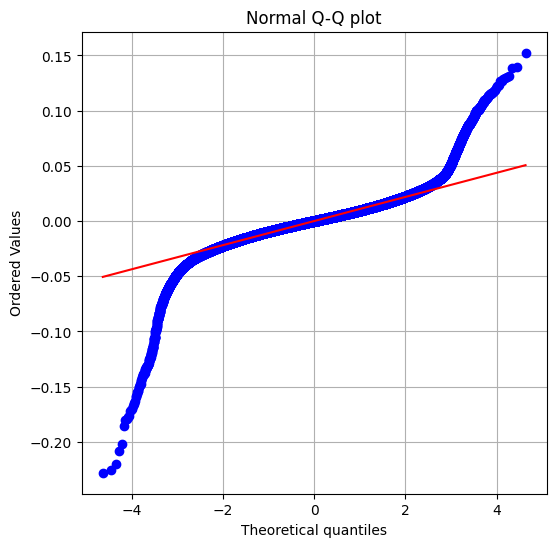

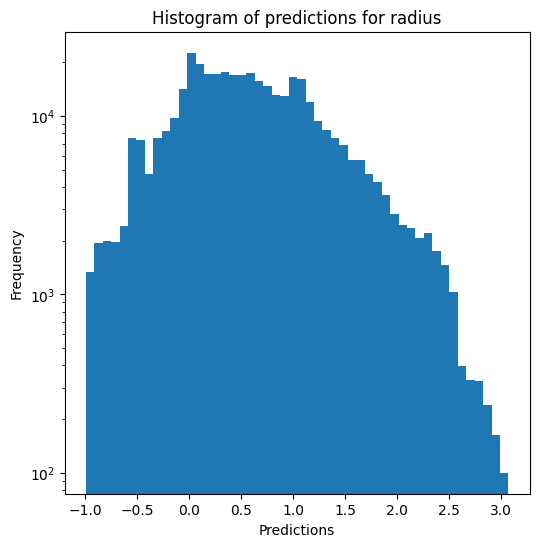

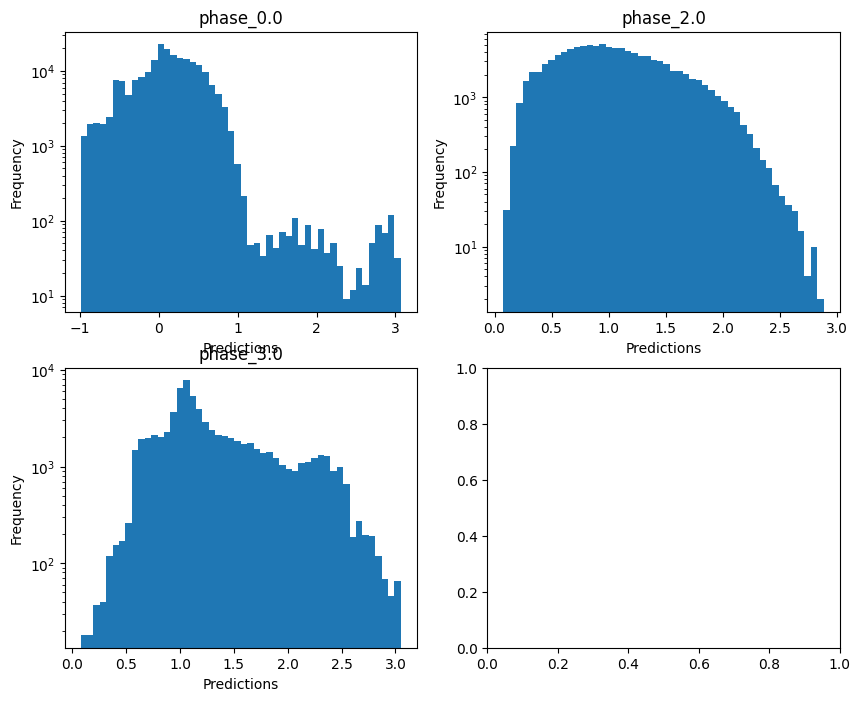

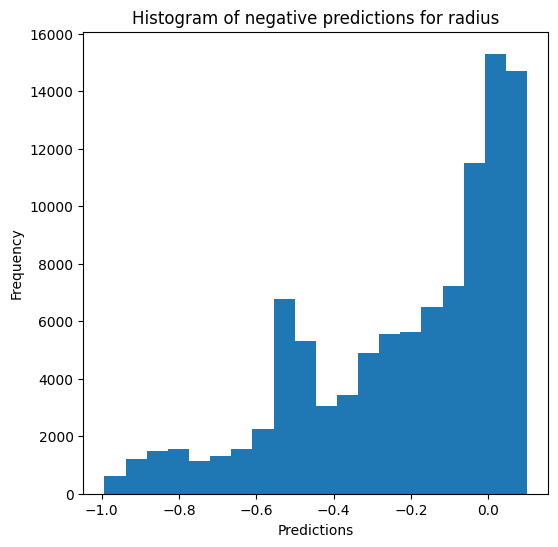

Saving predictions and results...


In [28]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [29]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_quantile_14 train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.003968978154944361
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.003808422843954907
3 

...

0.004225836310635412
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.003289560072421275
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0037104566026285334

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9977140474388649
  RMSE :  0.16225517401032655
  MAE :  0.07471963203794453
  MedAE :  0.03194402215261394
  CORR :  0.9989576778831922
  MAX_ER :  3.235093850494559
  Percentiles : 
    75th percentile :  0.07158283252248965
    90th percentile :  0.17125511076939193
    95th percentile :  0.2894409445288631
    99th percentile :  0.7334764248659432

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9988144186182598
  RMSE :  0.11233434640588874
  MAE :  0.06554246955098122
  MedAE :  0.03843737864603525
  CORR :  0.9994396232700711
  MAX_ER :  2.435917168634438
  Percentiles : 
    75th percentile :  0.0777789684840835
    90th percentile :  0.14505530528640428
    95th percentile :  0.22137200496405277
    99th percentile :  0.424863309137

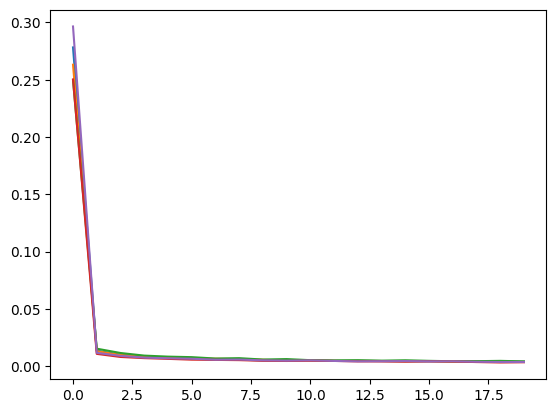

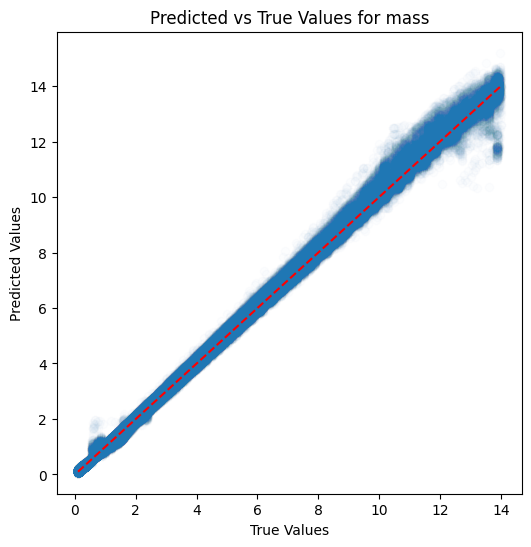

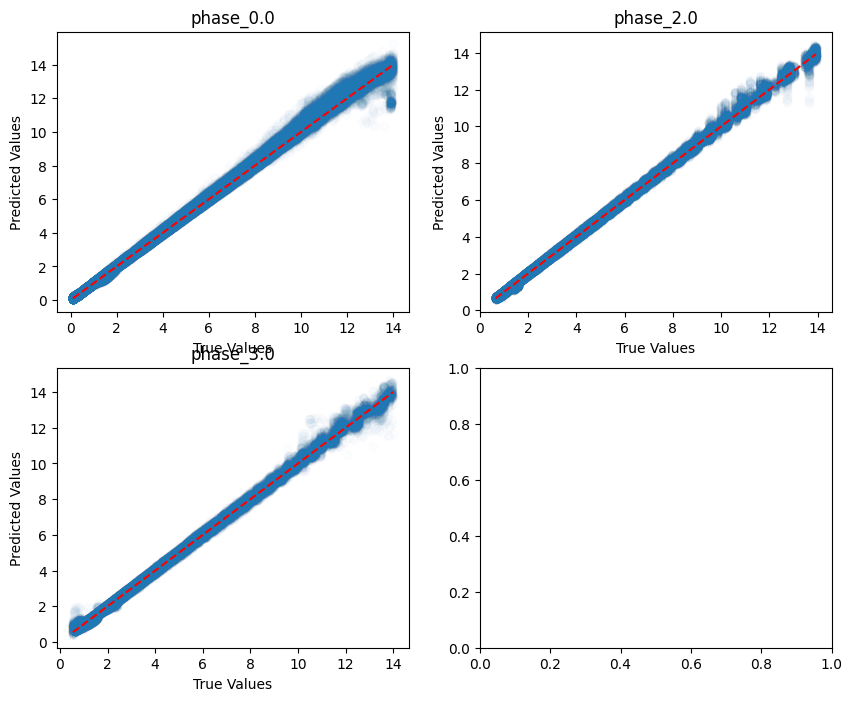

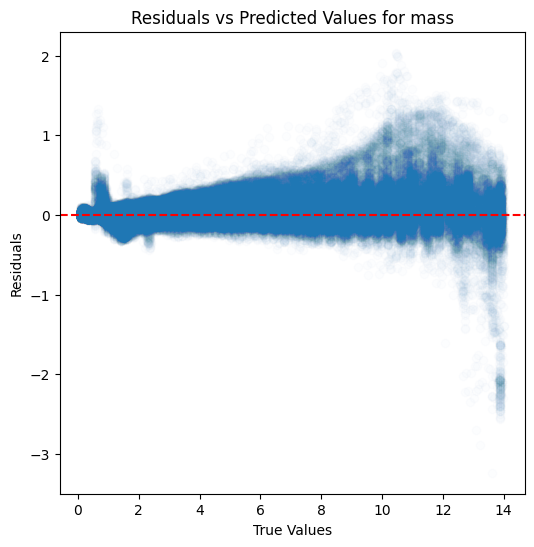

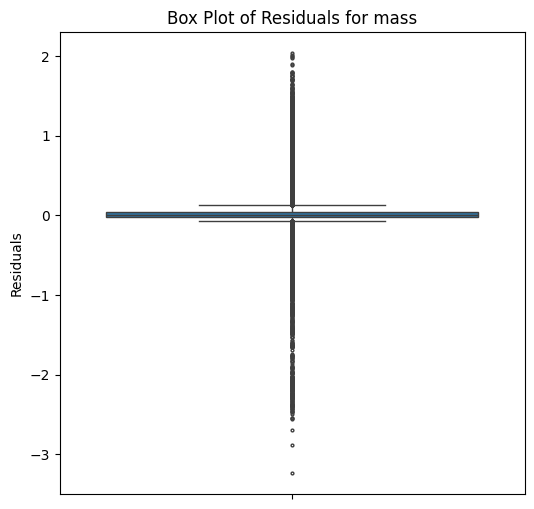

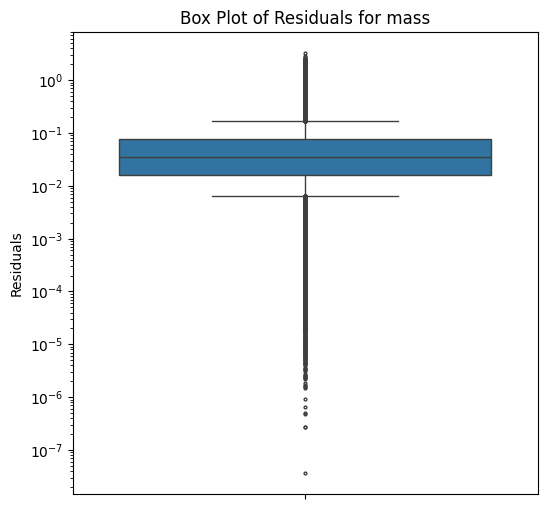

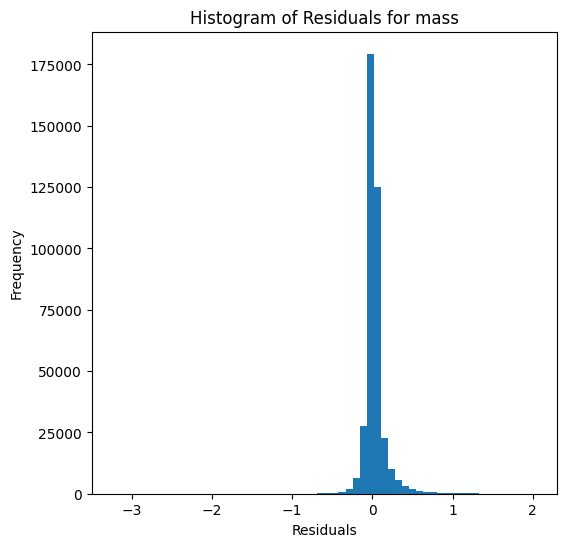

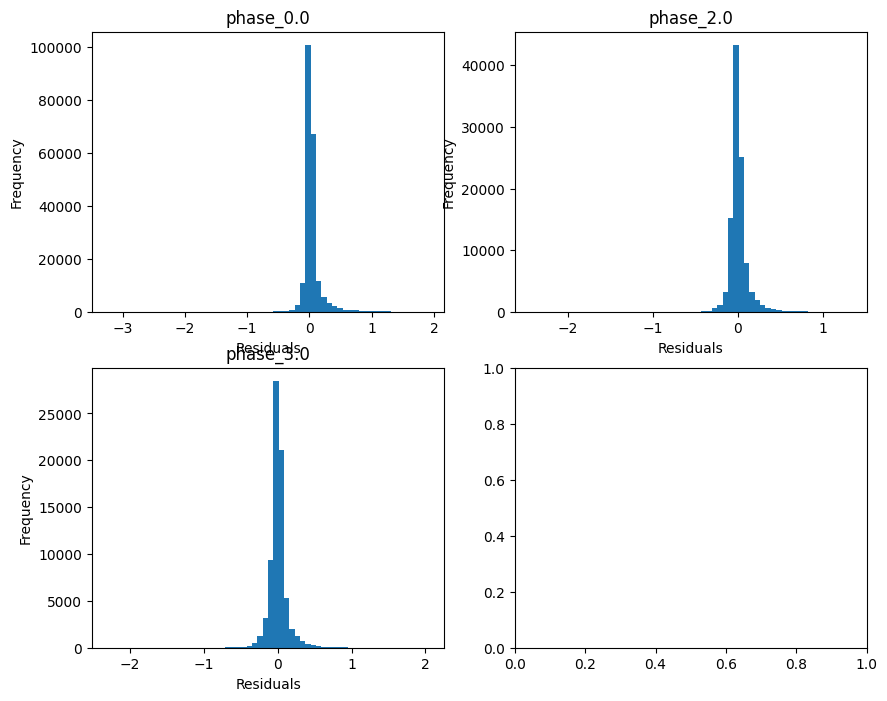

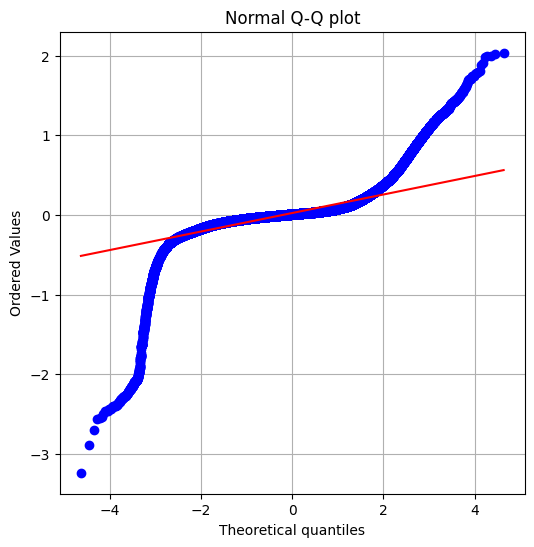

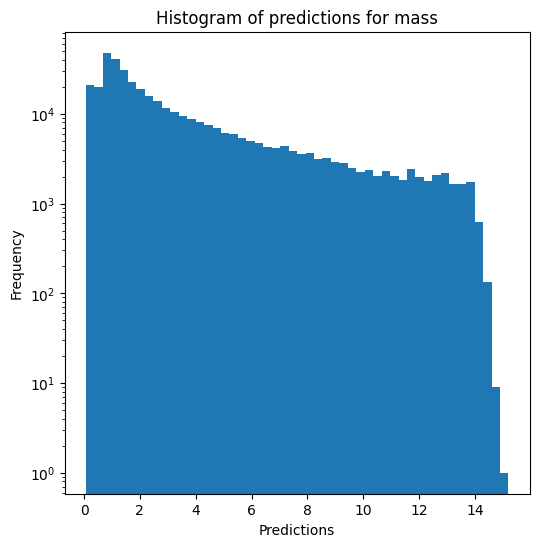

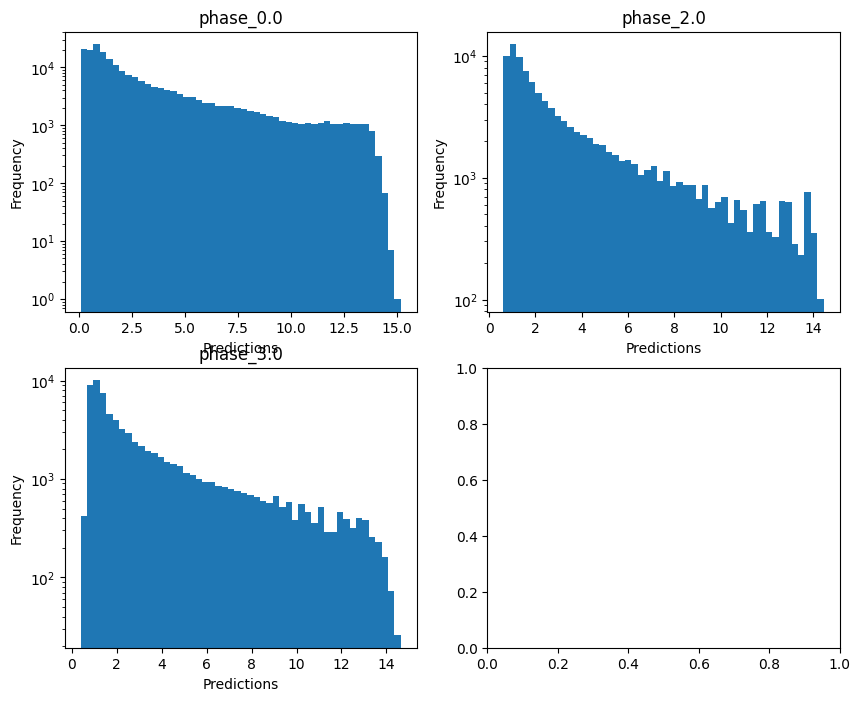

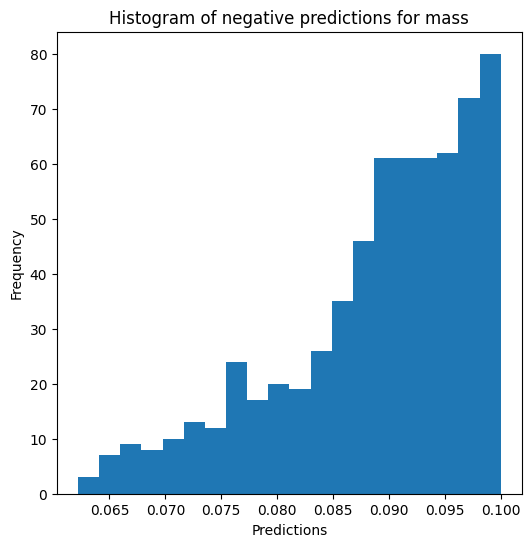


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9970719385446176
  RMSE :  0.0237178908528586
  MAE :  0.01661334744727663
  MedAE :  0.011226732474032136
  CORR :  0.9986189850579393
  MAX_ER :  0.22619607251134521
  Percentiles : 
    75th percentile :  0.021461285329908264
    90th percentile :  0.0403719475597467
    95th percentile :  0.05378910658089865
    99th percentile :  0.07619542659560687

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9966836194219592
  RMSE :  0.027666213388352335
  MAE :  0.02074766814691806
  MedAE :  0.015930773159755884
  CORR :  0.9983696436813128
  MAX_ER :  0.21140716035837714
  Percentiles : 
    75th percentile :  0.029216349470250202
    90th percentile :  0.044803919350427816
    95th percentile :  0.05517806846971825
    99th percentile :  0.08240020728054752

radius results for the phas

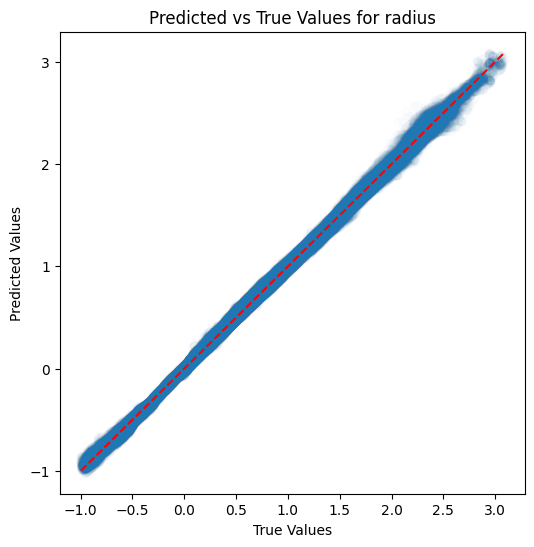

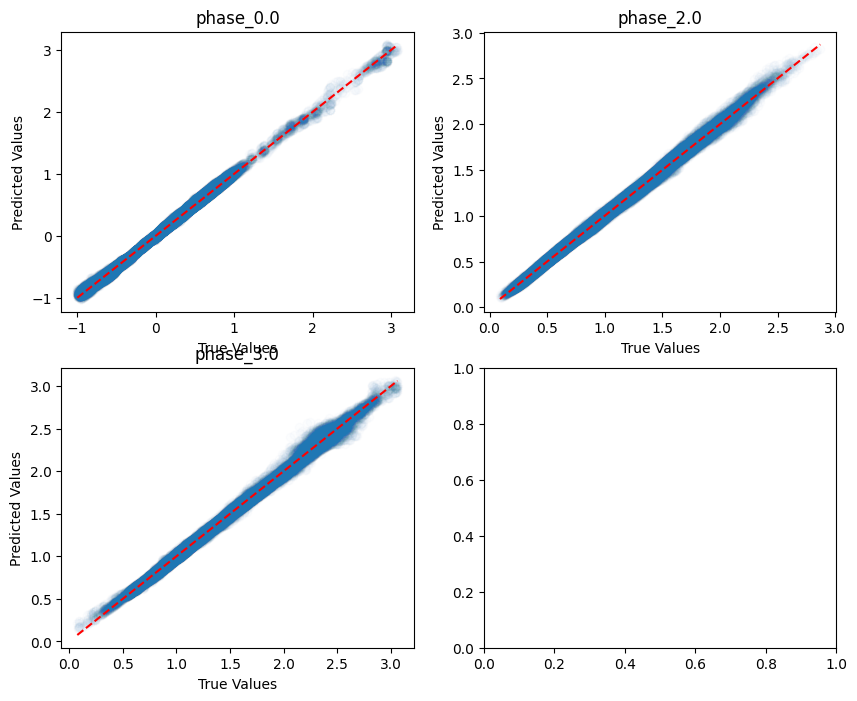

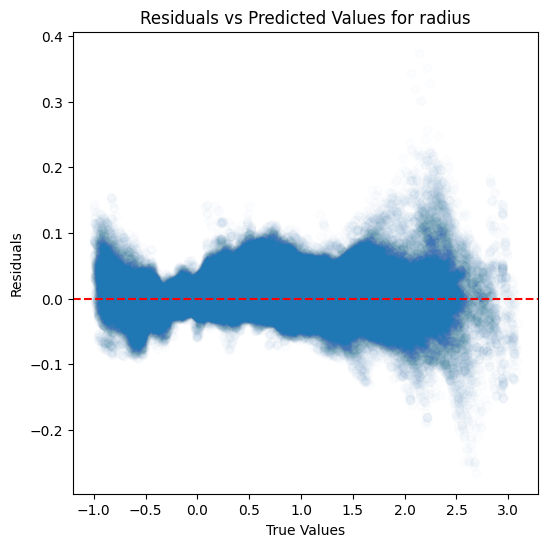

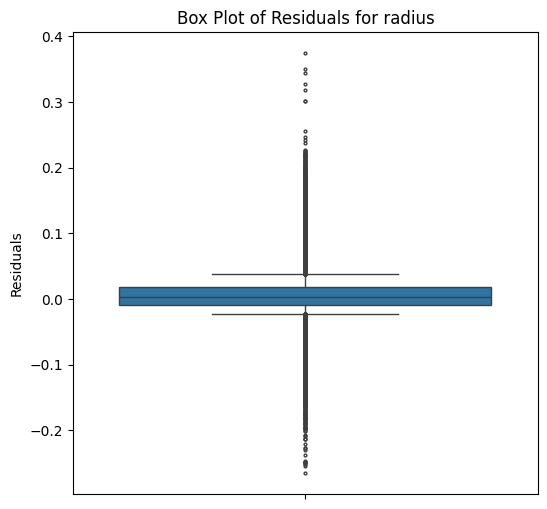

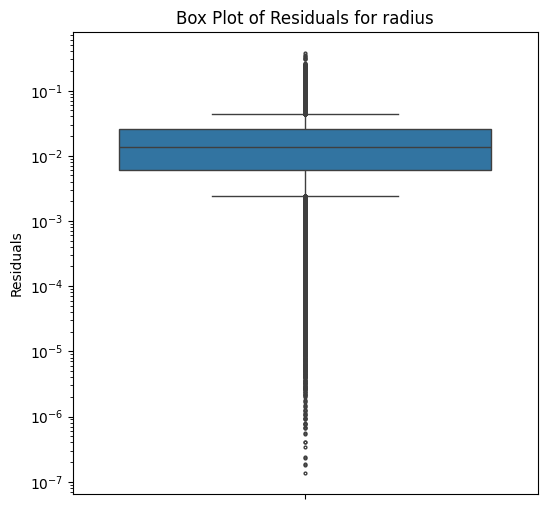

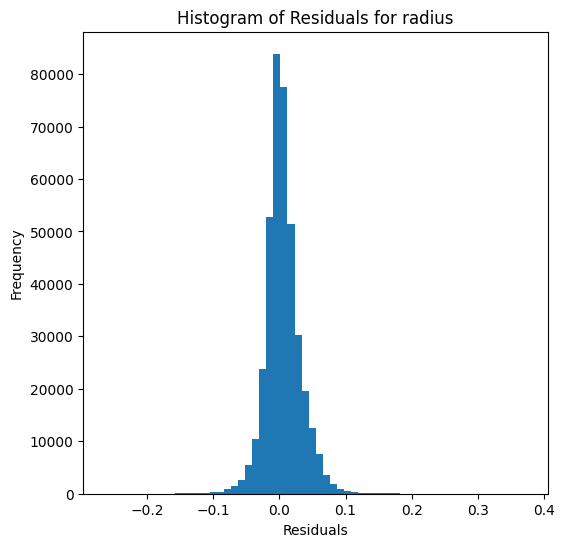

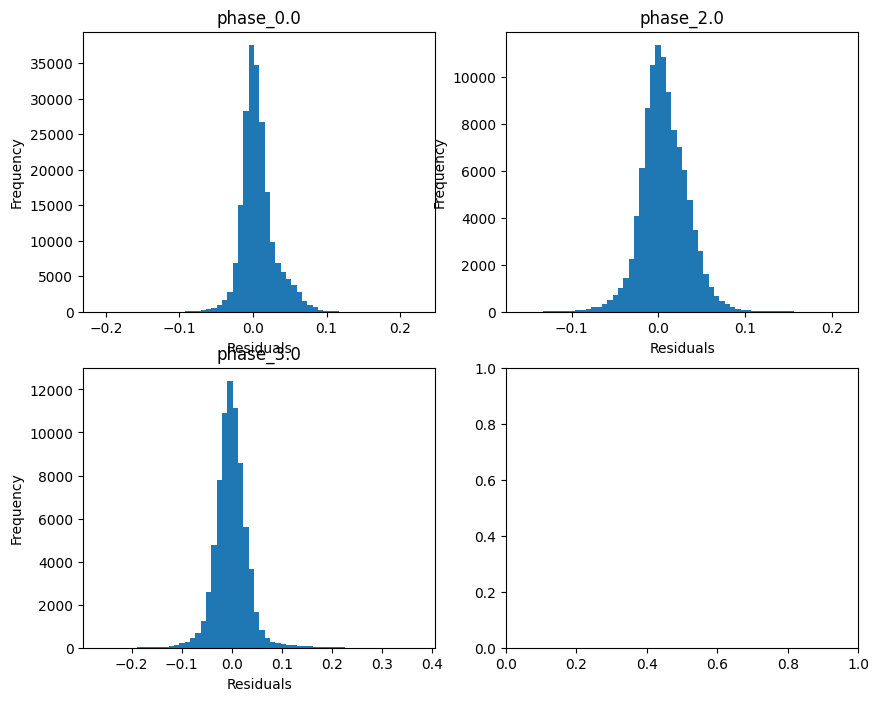

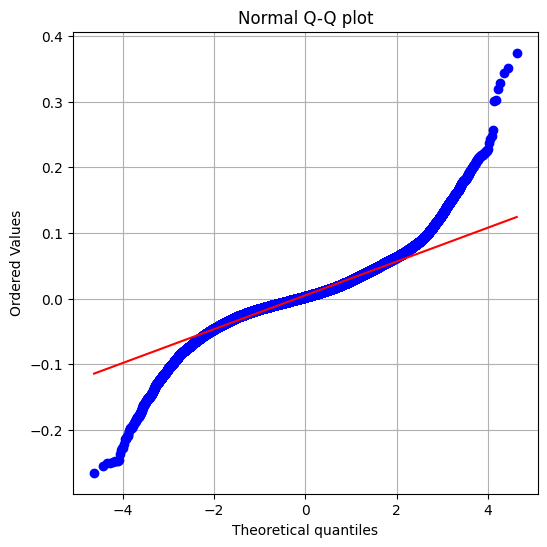

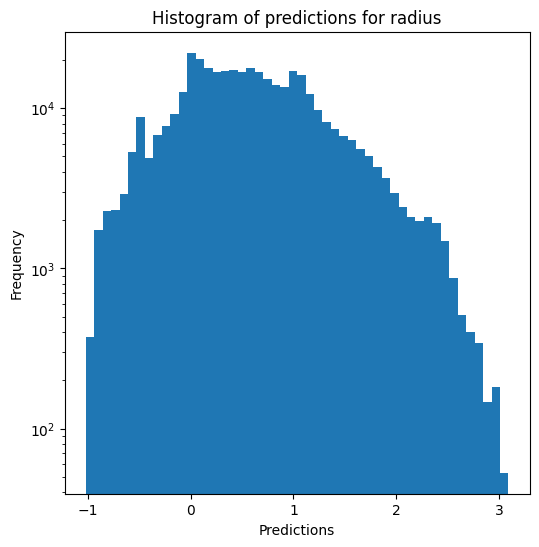

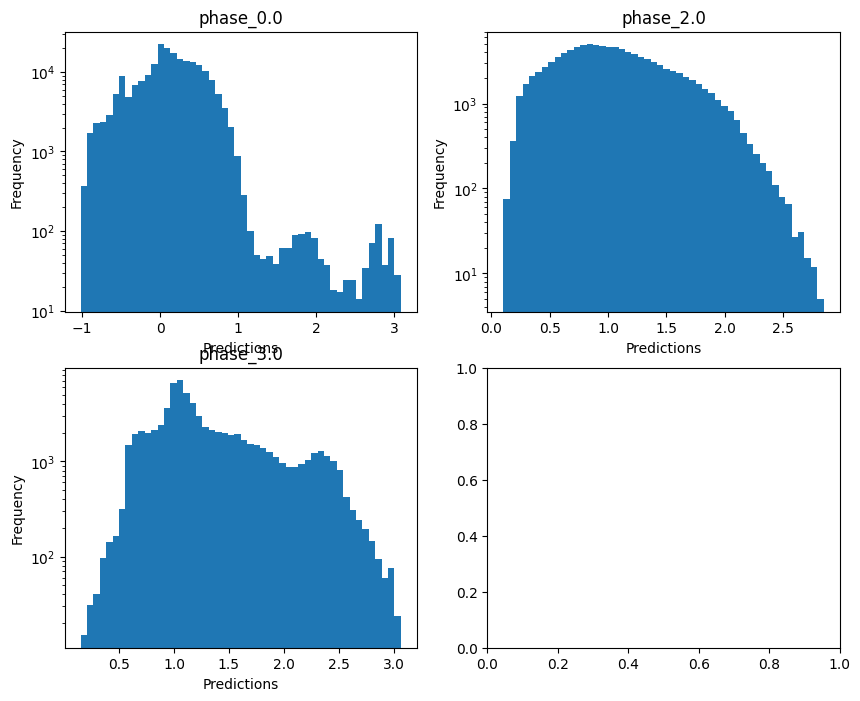

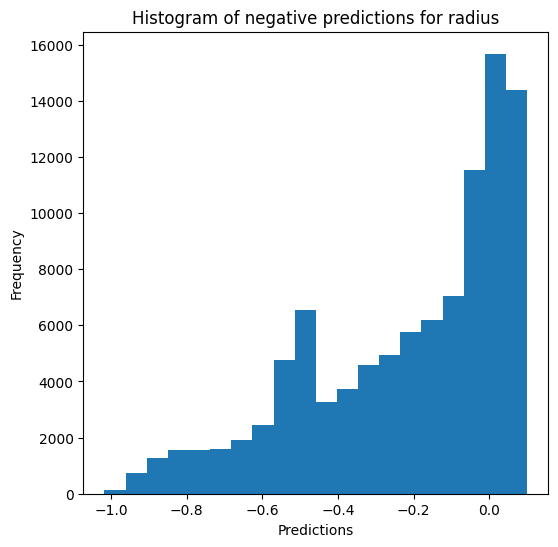

Saving predictions and results...


In [30]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon